<a href="https://colab.research.google.com/github/jackieeee3/MATH-456/blob/Homeworks/MATH_456_HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MATH 456: Introduction to Numerical Analysis II - Habbershaw**
## **Unit 1 Homework**

# **Exercise 1.1** (Best approximation geometry and (non)uniqueness).
*This problem isolates and examines the role of the norm in the bext approximation problem*
\
(a) (Analysis) Consider $X = \mathbb{R}^2$ with the $\ell^\infty$-norm $||x||_\infty$ = $\max\{|x_1|, |x_2|\}$ and the 1D subspace
$$V = \{(t, 0)^T: t \in \mathbb{R}\}$$
Let $t = (0, 1)^T \in X$. Find all minimizers of $\min_{v \in V} ||f - v||_\infty$ and show that the minimizer is not unique.

Let
$$f = (0, 1)^T \in X = \mathbb{R}^2$$
For any
$$v \in V, v = (t, 0)^T: t \in \mathbb{R}$$
Then,
$$f - v = (0 - t, 1 - 0) = (-t, 1)$$
Then,
$$||f - v||_\infty = \max_{v \in V}\{|-t|, |1|\} = \max_{v \in V} \{|t|, 1\}$$
$$= \begin{cases}
  1 & \text{if } t \le 1 \\
  |t| & \text{if } t > 1
\end{cases}$$
Therefore,
$$\min_{v \in V} ||f - v||_\infty = 1$$
with $t \in [-1, 1]$. There are infinitely many minimzers. Thus, the minimizer is not unique.

(b) (Analysis) Repeat part (a) with the 2-norm $||x||_2 = \sqrt{x_1^2 + x_2^2}$. Show that the minimizer is unique and identify it explicitly.

From the previous problem,
$$||f - v||_2 = \sqrt{(-t)^2 + 1^2} = \sqrt{t^2 + 1}$$
The equation is minimized when $t = 0$
$$\implies \sqrt{t^2 + 1} = \sqrt{0^2 + 1^2} = \sqrt{1} = 1$$
Thus,
$$\min_{v \in V} ||f - v||_2 = 1$$

(c) (Interpretation) In your own words, connect parts (a)-(b) to the Unit 1 notes: why does strict convexity (e.g. in $||\cdot||_2$) support uniqueness, and why can $||\cdot||_\infty$ behave differently?

Strictly convex norms have at most one global minimizer, thus making it unique. On the other hand, non-strictly convex norms can have a range of values that satisfy the minimizer criteria.

<div style="page-break-after: always;"></div>

# **Exercise 1.2** ($L^2$ best approximation: Gram matrix vs. orthogonal basis)
Let $f(x) = e^x$ on $[-1, 1]$ and $V = \mathbb{P}_2$
\
(a) (Analysis) In the monomial basis $\{1, x, x^2\}$, write $p(x) = c_0 + c_1x + c_2x^2$ and derive the Gram systen
$$Gc = b \quad G_{ij} = \int_{-1}^1 x^{i+j} dx, \quad b_i = \int_{-1}^1 f(x)x^i dx$$
for $i, j \in \{0, 1, 2\}$. Compute the Gram matrix $G$ and vector $b$ exactly.

Computing the Gram Matrix $G$:
$$G_{00} = \int_{-1}^1 x^0 dx = \int_{-1}^1 1 dx = \big[x\big]_{-1}^1 = 1 + 1 = 2$$
$$G_{01} = \int_{-1}^1 x dx = \Bigg[\frac{x^2}{2}\Bigg]_{-1}^1 = \frac{1}{2} - \frac{1}{2} = 0 = G_{10}$$
$$G_{02} = \int_{-1}^1 x^2 dx = \Bigg[\frac{x^3}{3}\Bigg]_{-1}^1 = \frac{1}{3} + \frac{1}{3} = \frac{2}{3} = G_{20} = G_{11}$$
$$G_{12} = \int_{-1}^1 x^2 dx = \Bigg[\frac{x^4}{4}\Bigg]_{-1}^1 = \frac{1}{4} - \frac{1}{4} = 0 = G_{21}$$
$$G_{22} = \int_{-1}^1 x^4 dx = \Bigg[\frac{x^5}{5}\Bigg]_{-1}^1 = \frac{1}{5} + \frac{1}{5} = \frac{2}{5}$$

Computing the vector $b$:
$$b_0 = \int_{-1}^1 e^x dx = \big[e^x\big]_{-1}^1 = e - e^{-1}$$
$$b_1 = \int_{-1}^1 xe^x dx \quad \text{Let } u = x^2, dv = e^x dx; v = e^x, du = dx$$
$$b_1 = \big[xe^x\big]_{-1}^1 - \int_{-1}^1 e^x dx = e + e^{-1} - (e - e^{-1}) = 2e^{-1}$$
$$b_2 = \int_{-1}^1 x^2 e^x dx \quad \text{Let } u = x^2, dv = e^x dx; v = e^x, du = 2x dx$$
$$b_2 = \big[x^2e^x\big]_{-1}^1 - 2 \int_{-1}^1 xe^x dx = e - e^{-1} - 4e^{-1} = e - 5e^{-1}$$

Thus, the Gram system
$$Gc = b \implies
\begin{pmatrix}
2 & 0 & 2/3 \\
0 & 2/3 & 0 \\
2/3 & 0 & 2/5
\end{pmatrix}
\begin{pmatrix}
c_0 \\
c_1 \\
c_2
\end{pmatrix}
=
\begin{pmatrix}
e - e^{-1} \\
2e^{-1} \\
e - 5e^{-1}
\end{pmatrix}$$


(b) (Analysis + Computational) Compute c exactly by inverting G. Report $c_0, c_1, c_2$ and plot $f$ and $p$ on $[-1, 1]$. Also report the $L^2$ norm $||f - p||_2$ (you may approximate this integral numerically).

Import numpy:

In [1]:
import numpy as np

Define the Gram matrix $G$ and vector $b$:

In [2]:
G = np.array([
    [2, 0, 2/3],
    [0, 2/3, 0],
    [2/3, 0, 2/5]
])

b = np.array([
    np.exp(1) - np.exp(-1),
    2 * np.exp(-1),
    np.exp(1) - 5 * np.exp(-1)
])

print("Gram matrix G:\n", G)
print("\nVector b:\n", b)

Gram matrix G:
 [[2.         0.         0.66666667]
 [0.         0.66666667 0.        ]
 [0.66666667 0.         0.4       ]]

Vector b:
 [2.35040239 0.73575888 0.87888462]


Solve for $c$:

In [3]:
c = np.linalg.solve(G, b)

print("Coefficients c (c0, c1, c2):\n", c)

Coefficients c (c0, c1, c2):
 [0.99629402 1.10363832 0.53672153]


Calculating $f$ and $p$:

In [4]:
def f(x):
    return np.exp(x)

def p(x, c):
    return c[0] + c[1]*x + c[2]*(x**2)

x_values = np.linspace(-1, 1, 100)
f_values = f(x_values)
p_values = p(x_values, c)

Plotting values of $f$ and $p$ on the interval $[-1.1]$:

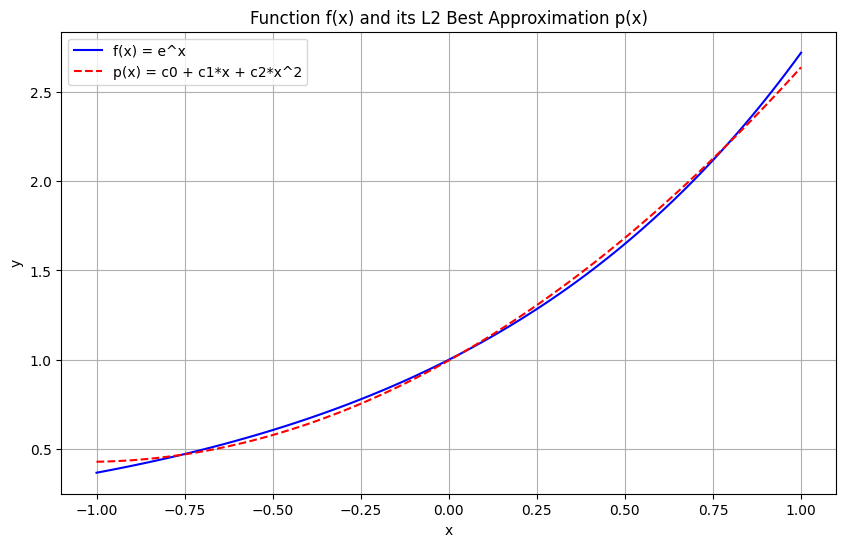

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x_values, f_values, label='f(x) = e^x', color='blue')
plt.plot(x_values, p_values, label='p(x) = c0 + c1*x + c2*x^2', color='red', linestyle='--')
plt.title('Function f(x) and its L2 Best Approximation p(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Approximating the $L^2$ norm $||f - p||_2$:

In [6]:
l2_norm_squared = np.trapezoid((f_values - p_values)**2, x_values)
l2_norm = np.sqrt(l2_norm_squared)

print(f"c0: {c[0]:.6f}")
print(f"c1: {c[1]:.6f}")
print(f"c2: {c[2]:.6f}")
print(f"L2 norm ||f - p||_2: {l2_norm:.6f}")

c0: 0.996294
c1: 1.103638
c2: 0.536722
L2 norm ||f - p||_2: 0.038013


(c) (Analysis + Interpretation) Repeat the computation using the Legendre basis $(P_0, P_1, P_2)$ (see Section 1.4.1 of the course notes for definitions of $P_k$) and the projection formula
$$x_k = \frac{\int_{-1}^1 f(x) P_k(x) dx}{\int_{-1}^1 P_k(x)^2 dx} \quad k = 0, 1, 2$$
and then convert the resulting polynomial back into the monomial form. Compare coefficient vectors and comment on: (i) numerical stability/conditioning, (ii) the "decouping" advantage of an orthogonal basis

The Legendre polynomials are defined as
$$P_0(x) = 1, P_1(x) = x, P_2(x) = \frac{1}{2}(3x^2 - 1)$$
For Legendre polynomials, the normalization is known explicitly
$$\int_{-1}^1 P_k(x)^2 dx = \frac{2}{2k + 1}$$
Thus, the projections are
$$x_0 = \frac{\int_{-1}^1 e^x dx}{\int_{-1}^1 P_0(x)^2 dx} = \frac{\big[e^x\big]_{-1}^1}{2} = \frac{e - e^{-1}}{2}$$
$$x_1 = \frac{\int_{-1}^1 xe^x dx}{\int_{-1}^1 P_1(x)^2 dx} = \frac{2e^{-1}}{2/3} = \frac{6e^{-1}}{2} = 3e^{-1}$$
$$x_2 = \frac{\frac{1}{2} \int_{-1}^1 e^x(3x^2 - 1) dx}{\int_{-1}^1 P_2(x)^2 dx} = \frac{\frac{1}{2}(3(e - 5e^{-1}) - (e - e^{-1}))}{2/5} = \frac{\frac{1}{2}(3e - 15e^{-1} - e + e^{-1}}{2/5} = \frac{\frac{1}{2}(2e - 14e^{-1})}{2/5} = \frac{e - 7e^{-1}}{2/5} = \frac{5}{2}(e - 7e^{-1})$$


Thus, the resulting polynomial is
$$p(x) = x_0P_0(x) + x_1P_1(x) + x_2P_2(x)$$
$$= \frac{e - e^{-1}}{2} + 3e^{-1}x + \frac{5}{2}\Big(e - 7e^{-1}\Big)\frac{1}{2}\Big(3x^2 - 1\Big)$$
$$ = \frac{1}{2}e - \frac{1}{2}e^{-1} + 3e^{-1}x + \Big(\frac{5}{2}e - \frac{35}{2}e^{-1}\Big)\Big(\frac{3}{2}x^2 - \frac{1}{2}\Big)$$
$$\frac{1}{2}e - \frac{1}{2}e^{-1} + 3e^{-1}x + \frac{15}{4}ex^2 - \frac{5}{4}e - \frac{105}{4}e^{-1}x^2 + \frac{35}{4}e^{-1}$$
$$\underbrace{-\frac{3}{4}e + \frac{33}{4}e^{-1}}_{c_0} + \underbrace{3e^{-1}}_{c_1}x + \underbrace{\Big(\frac{15}{4}e - \frac{105}{4}e^{-1}\Big)}_{c_2}x^2$$
$$\implies c =
\begin{pmatrix}
\frac{3}{4}(-e + 11e^{-1}) \\
3e^{-1} \\
\frac{15}{4}(e - 7e^{-1})
\end{pmatrix}$$

The monomial basis leads to a dense and ill-conditioned Gram matrix where each coefficient depends on others. Also, conditioning worsens as degree increases. For the Legendre basis, the orthogonal basis leads to a diagonal Gram matrix where each coefficient is computed independently.

<div style="page-break-after: always;"></div>

# **Exercise 1.3** (Interpolation vs. least squares on noisy data)
Let $f_1(x) = \cos(2\pi x)$ and $f_2(x) = \cos^2(2\pi x)$ on $[0, 1]$. Let $m \ge 50$ and define data sites $x_i = i/m$ for $i = 0, ..., m$. Create noisy observations
$$y_i = f(x_i) + \eta_i$$
where $\eta_i$ are i.i.d. mean-zero Gaussian noise with standard deviation $\sigma = 0.05$ (set a fixed random seed).
\
(a) (Computational) For a fixed degree $n \in \{5, 10, 15\}$, compute
  * the degree-m interpolating piecewise linear spline through $(x_i, y_i)$ (i.e. connect-the-dots)
  * the degree-n least squares polynomial fit $p_n \in \mathbb{P}_n$ that minimizes $\sum_{i=0}^m |p_n(x_i) - y_i|^2$

For each function $f_1$ and $f_2$, plot the true function, the noisy data, and the approximants (linear spline and least square polynomial fit) on the same axes


Importing libraries, defining functions, setting parameters, and generating noisy data:

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Define the true functions
def f1(x):
    return np.cos(2 * np.pi * x)

def f2(x):
    return np.cos(2 * np.pi * x)**2

# Set up parameters
m = 100  # Number of data sites (>= 50)
sigma = 0.05  # Standard deviation for noise
np.random.seed(42)  # Fixed random seed for reproducibility

# Generate data sites
x_values = np.linspace(0, 1, m + 1)

# Generate noisy observations
noise = np.random.normal(0, sigma, m + 1)
y1_noisy = f1(x_values) + noise
y2_noisy = f2(x_values) + noise

Creating function $f_1$ and plot:

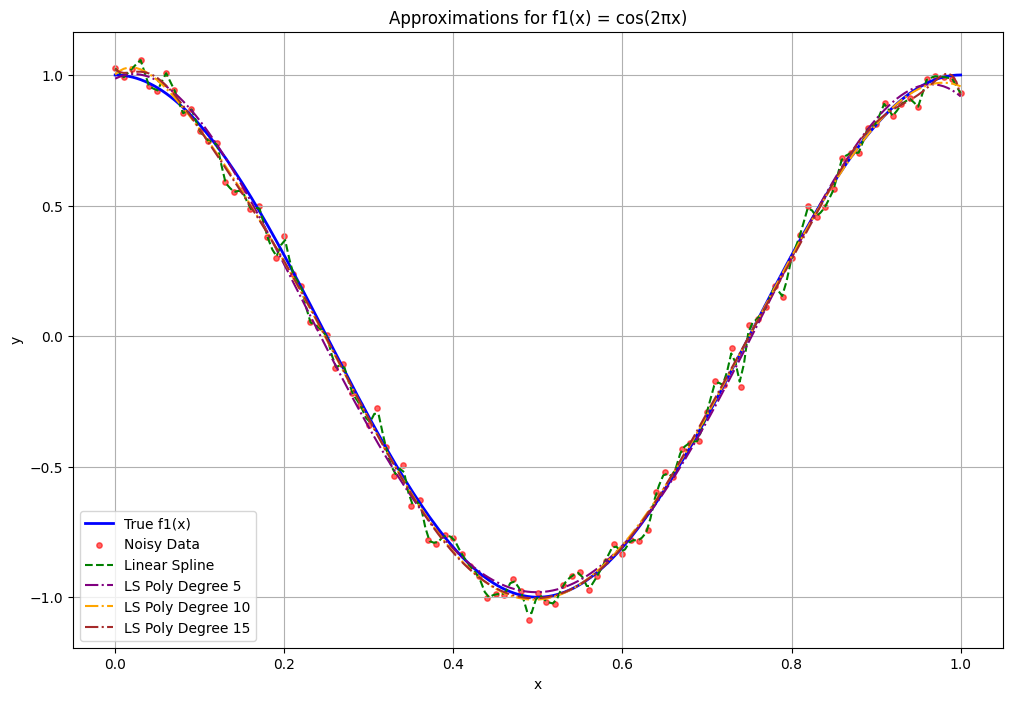

In [8]:
# 1. Create a linear interpolation function
linear_spline_f1 = interp1d(x_values, y1_noisy, kind='linear')

# 2. Define polynomial degrees
n_degrees = [5, 10, 15]

# Store polynomial fit functions
poly_fits_f1 = {}
for n in n_degrees:
    # 3a. Use np.polyfit to compute coefficients
    coeffs = np.polyfit(x_values, y1_noisy, n)
    # 3b. Create a polynomial function
    poly_fits_f1[n] = np.poly1d(coeffs)

# 4. Create a new set of x values for plotting
x_plot = np.linspace(0, 1, 200) # Finer resolution for smooth curves

# 5. Calculate true f1 values for x_plot
f1_true_values = f1(x_plot)

# 6. Calculate linear spline values for x_plot
linear_spline_values = linear_spline_f1(x_plot)

# 7. Calculate polynomial fit values for x_plot for each degree
poly_fit_values_f1 = {n: poly_fits_f1[n](x_plot) for n in n_degrees}

# 8. Plotting
plt.figure(figsize=(12, 8))
plt.plot(x_plot, f1_true_values, label='True f1(x)', color='blue', linewidth=2)
plt.scatter(x_values, y1_noisy, label='Noisy Data', color='red', alpha=0.6, s=15)
plt.plot(x_plot, linear_spline_values, label='Linear Spline', color='green', linestyle='--')

colors = ['purple', 'orange', 'brown']
for i, n in enumerate(n_degrees):
    plt.plot(x_plot, poly_fit_values_f1[n], label=f'LS Poly Degree {n}', color=colors[i], linestyle='-.')

# 9. Add title
plt.title('Approximations for f1(x) = cos(2πx)')
# 10. Label axes
plt.xlabel('x')
plt.ylabel('y')
# 11. Include a legend
plt.legend()
plt.grid(True)
# 12. Display the plot
plt.show()

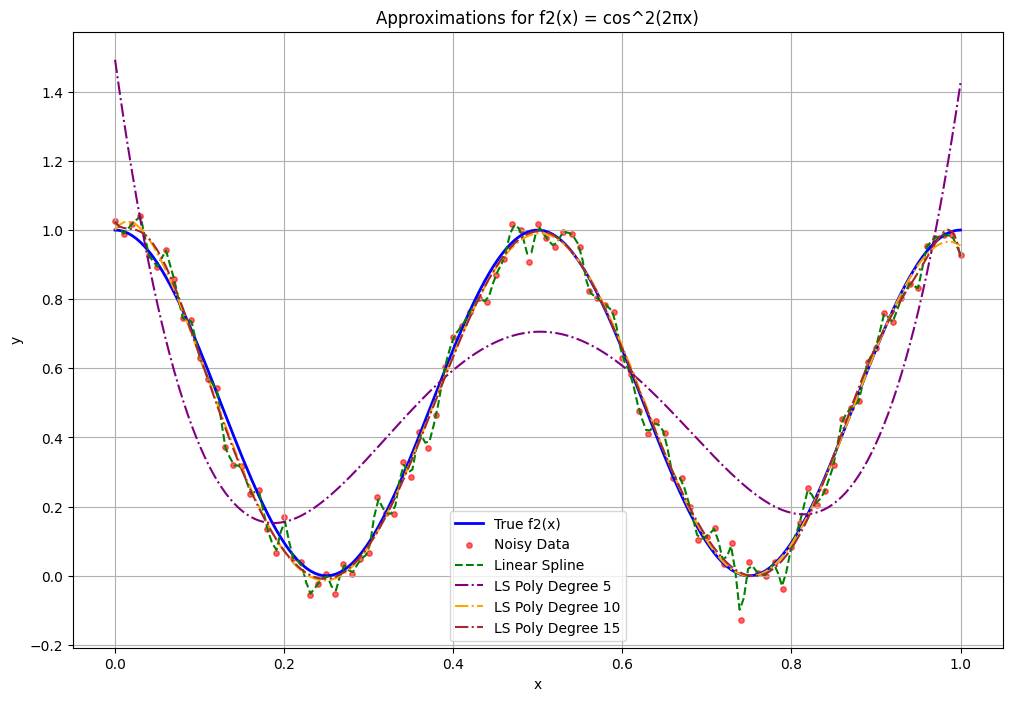

In [9]:
# 1. Create a linear interpolation function
linear_spline_f2 = interp1d(x_values, y2_noisy, kind='linear')

# 2. Define polynomial degrees (already defined, but explicit for clarity)
n_degrees = [5, 10, 15]

# Store polynomial fit functions
poly_fits_f2 = {}
for n in n_degrees:
    # 3a. Use np.polyfit to compute coefficients
    coeffs = np.polyfit(x_values, y2_noisy, n)
    # 3b. Create a polynomial function
    poly_fits_f2[n] = np.poly1d(coeffs)

# 4. Create a new set of x values for plotting (already defined as x_plot)
x_plot = np.linspace(0, 1, 200) # Finer resolution for smooth curves

# 5. Calculate true f2 values for x_plot
f2_true_values = f2(x_plot)

# 6. Calculate linear spline values for x_plot
linear_spline_values_f2 = linear_spline_f2(x_plot)

# 7. Calculate polynomial fit values for x_plot for each degree
poly_fit_values_f2 = {n: poly_fits_f2[n](x_plot) for n in n_degrees}

# 8. Plotting
plt.figure(figsize=(12, 8))
plt.plot(x_plot, f2_true_values, label='True f2(x)', color='blue', linewidth=2)
plt.scatter(x_values, y2_noisy, label='Noisy Data', color='red', alpha=0.6, s=15)
plt.plot(x_plot, linear_spline_values_f2, label='Linear Spline', color='green', linestyle='--')

colors = ['purple', 'orange', 'brown'] # Reusing colors from f1 plot for consistency
for i, n in enumerate(n_degrees):
    plt.plot(x_plot, poly_fit_values_f2[n], label=f'LS Poly Degree {n}', color=colors[i], linestyle='-.')

# 9. Add title
plt.title('Approximations for f2(x) = cos^2(2πx)')
# 10. Label axes
plt.xlabel('x')
plt.ylabel('y')
# 11. Include a legend
plt.legend()
plt.grid(True)
# 12. Display the plot
plt.show()

(b) (Computational) On a fine test grid, report:
$$E_\infty = \max|(approx)(x) - f(x)| \quad E_2 = \Bigg(\int_0^1 |(approx)(x) - f(x)|^2 dx \Bigg)^{1/2}$$
(for each approximant, approximating the $E_2$ integral numerically, e.g., with a trapezoidal quadrature rule)

Defining fine test grid:

In [10]:
x_test = x_plot
f1_true_values_on_test_grid = f1_true_values
f2_true_values_on_test_grid = f2_true_values

Calculating $f_1$ errors:

In [11]:
f1_errors = {}

# Calculate errors for linear spline approximant of f1(x)
abs_diff_linear_spline = np.abs(linear_spline_values - f1_true_values_on_test_grid)
e_inf_linear_spline = np.max(abs_diff_linear_spline)
e2_linear_spline = np.sqrt(np.trapezoid(abs_diff_linear_spline**2, x_test))
f1_errors['Linear Spline'] = {'E_inf': e_inf_linear_spline, 'E2': e2_linear_spline}

# Calculate errors for polynomial fits of f1(x)
for n in n_degrees:
    poly_approx_values = poly_fits_f1[n](x_test)
    abs_diff_poly = np.abs(poly_approx_values - f1_true_values_on_test_grid)
    e_inf_poly = np.max(abs_diff_poly)
    e2_poly = np.sqrt(np.trapezoid(abs_diff_poly**2, x_test))
    f1_errors[f'Polynomial Degree {n}'] = {'E_inf': e_inf_poly, 'E2': e2_poly}

# Print the results in a clear format
print("Error metrics for f1(x) approximants:")
for approx_type, errors in f1_errors.items():
    print(f"  {approx_type}:")
    print(f"    E_inf: {errors['E_inf']:.6f}")
    print(f"    E2: {errors['E2']:.6f}")

Error metrics for f1(x) approximants:
  Linear Spline:
    E_inf: 0.103633
    E2: 0.037133
  Polynomial Degree 5:
    E_inf: 0.081875
    E2: 0.022866
  Polynomial Degree 10:
    E_inf: 0.043527
    E2: 0.015974
  Polynomial Degree 15:
    E_inf: 0.076697
    E2: 0.017649


Calculating $f_2$ errors:

In [12]:
f2_errors = {}

# Calculate errors for linear spline approximant of f2(x)
abs_diff_linear_spline_f2 = np.abs(linear_spline_values_f2 - f2_true_values_on_test_grid)
e_inf_linear_spline_f2 = np.max(abs_diff_linear_spline_f2)
e2_linear_spline_f2 = np.sqrt(np.trapezoid(abs_diff_linear_spline_f2**2, x_test))
f2_errors['Linear Spline'] = {'E_inf': e_inf_linear_spline_f2, 'E2': e2_linear_spline_f2}

# Calculate errors for polynomial fits of f2(x)
for n in n_degrees:
    poly_approx_values_f2 = poly_fits_f2[n](x_test)
    abs_diff_poly_f2 = np.abs(poly_approx_values_f2 - f2_true_values_on_test_grid)
    e_inf_poly_f2 = np.max(abs_diff_poly_f2)
    e2_poly_f2 = np.sqrt(np.trapezoid(abs_diff_poly_f2**2, x_test))
    f2_errors[f'Polynomial Degree {n}'] = {'E_inf': e_inf_poly_f2, 'E2': e2_poly_f2}

# Print the results in a clear format
print("\nError metrics for f2(x) approximants:")
for approx_type, errors in f2_errors.items():
    print(f"  {approx_type}:")
    print(f"    E_inf: {errors['E_inf']:.6f}")
    print(f"    E2: {errors['E2']:.6f}")


Error metrics for f2(x) approximants:
  Linear Spline:
    E_inf: 0.103211
    E2: 0.037112
  Polynomial Degree 5:
    E_inf: 0.492586
    E2: 0.201344
  Polynomial Degree 10:
    E_inf: 0.044866
    E2: 0.015961
  Polynomial Degree 15:
    E_inf: 0.076699
    E2: 0.017649


(c) (Interpretation) Which method captues the underlying function better in $E_\infty$ vs. $E_2$? Give a short explanation using the Unit 1 themes: interpolation vs. approximation, and the role of the metric.

Initially, interpolation captures the underlying function better in $E_\infty$. However, approximation captures the underlying function better in both $E_\infty$ and $E_2$, especially as degree increases. This is mainly due to the fact that interpolation has to pass through every point (noise) and $E_\infty$ captures the worst case error, which is probably less than the worst case error for an approximation using a polynomial of degree 5. But, as degree increases, the approximation gets better, thus decreasing the worst case error as well as the overall error which $E_2$ measures.

<div style="page-break-after: always;"></div>

# **Exercise 1.4** (Cubic splines via the Hermite form (uniform grid))
This exercise follows the Unit 1 derivation in the slope formulation $D_k = s'(x_k)$ on a uniform grid (Section 1.7). Let $f_1(x) = \cos^4(2\pi x)$ and $f_2(x) = \tanh(50(x - 0.3))$ on $[0, 1]$, and choose $m \in \{10, 20, 40, 80\}$ with uniform knots $x_k = k/m$ and data $y_k = f(x_k)$
\
(a) (Computational) For each function $\{f_{\ell}\}_{\ell = 1}^2$, compute the natural cubic spline on the uniform grid $x_k = k/m, (k = 0, ..., m)$. Let $y_k = f_{\ell}(x_k)$ and $h = 1/m$ for $\ell \in \{1, 2\}$. To compute the spline function, do the following:
\
(i) Solve for the slopes $D_k = s'(x_k)$ from the tridiagonal system
$$2D_0 + D_1 = \frac{3}{h}(y_1 - y_0)$$
$$D_{k-1} + 4D_k + D_{k+1} = \frac{3}{h}(y_{k+1} - y_{k-1}), k = 1, ..., m - 1$$
(ii) Evaluate the spline interval-by-interval with the Hermite formula: for $x \in [x_k, x_{k+1}]$ set $t = (x - x_k)/h$ and use
$$s_k(x) = y_kH_{00}(t) + y_{k+1}H_{01}(t) + hD_kH_{10}(t) + hD_{k+1}H_{11}(t)$$

Define functions and Hermite basis:

In [13]:
import numpy as np

# Define the functions f1(x) and f2(x)
def f1(x):
    return np.cos(2 * np.pi * x)**4

def f2(x):
    return np.tanh(50 * (x - 0.3))

# Define the Hermite basis polynomials
def H00(t):
    return (1 + 2 * t) * (1 - t)**2

def H01(t):
    return t**2 * (3 - 2 * t)

def H10(t):
    return t * (1 - t)**2

def H11(t):
    return t**2 * (t - 1)

Solve for slopes $D_k$:

In [14]:
import numpy as np

def solve_slopes(y_k, h, m):
    # Initialize the (m+1) x (m+1) matrix A and (m+1) vector b
    A = np.zeros((m + 1, m + 1))
    b = np.zeros(m + 1)

    # Apply left boundary condition: 2D_0 + D_1 = (3/h)(y_1 - y_0)
    A[0, 0] = 2
    A[0, 1] = 1
    b[0] = (3 / h) * (y_k[1] - y_k[0])

    # Apply interior conditions: D_{k-1} + 4D_k + D_{k+1} = (3/h)(y_{k+1} - y_{k-1}) for k = 1, ..., m-1
    for k in range(1, m):
        A[k, k - 1] = 1
        A[k, k] = 4
        A[k, k + 1] = 1
        b[k] = (3 / h) * (y_k[k + 1] - y_k[k - 1])

    # Apply right boundary condition: D_{m-1} + 2D_m = (3/h)(y_m - y_{m-1})
    A[m, m - 1] = 1
    A[m, m] = 2
    b[m] = (3 / h) * (y_k[m] - y_k[m - 1])

    # Solve the system AD = b for D
    D = np.linalg.solve(A, b)
    return D


Evaluating splines:

In [15]:
import numpy as np

def evaluate_spline(x_eval, x_k, y_k, D_k, h):
    s_eval = np.zeros_like(x_eval, dtype=float)
    m = len(x_k) - 1 # Number of intervals

    for i, x in enumerate(x_eval):
        # Determine the interval [x_k, x_{k+1}] where x falls
        # Use searchsorted for efficient interval finding
        # np.searchsorted returns the index k such that x_k <= x < x_{k+1}
        # For x = x_m, it will return m, which needs special handling
        k = np.searchsorted(x_k, x, side='right') - 1

        # Handle edge case for x = x_m (the last knot)
        if k == m: # If x is exactly the last knot, use the last interval's data
            k = m - 1
        elif k < 0: # If x is before the first knot, treat it as the first interval (or extrapolate if needed, but problem implies within [0,1])
             k = 0

        # Calculate local parameter t
        t = (x - x_k[k]) / h

        # Evaluate spline using Hermite formula
        s_eval[i] = y_k[k] * H00(t) + \
                    y_k[k+1] * H01(t) + \
                    h * D_k[k] * H10(t) + \
                    h * D_k[k+1] * H11(t)

    return s_eval


Plotting underlying functions and apline approximations:

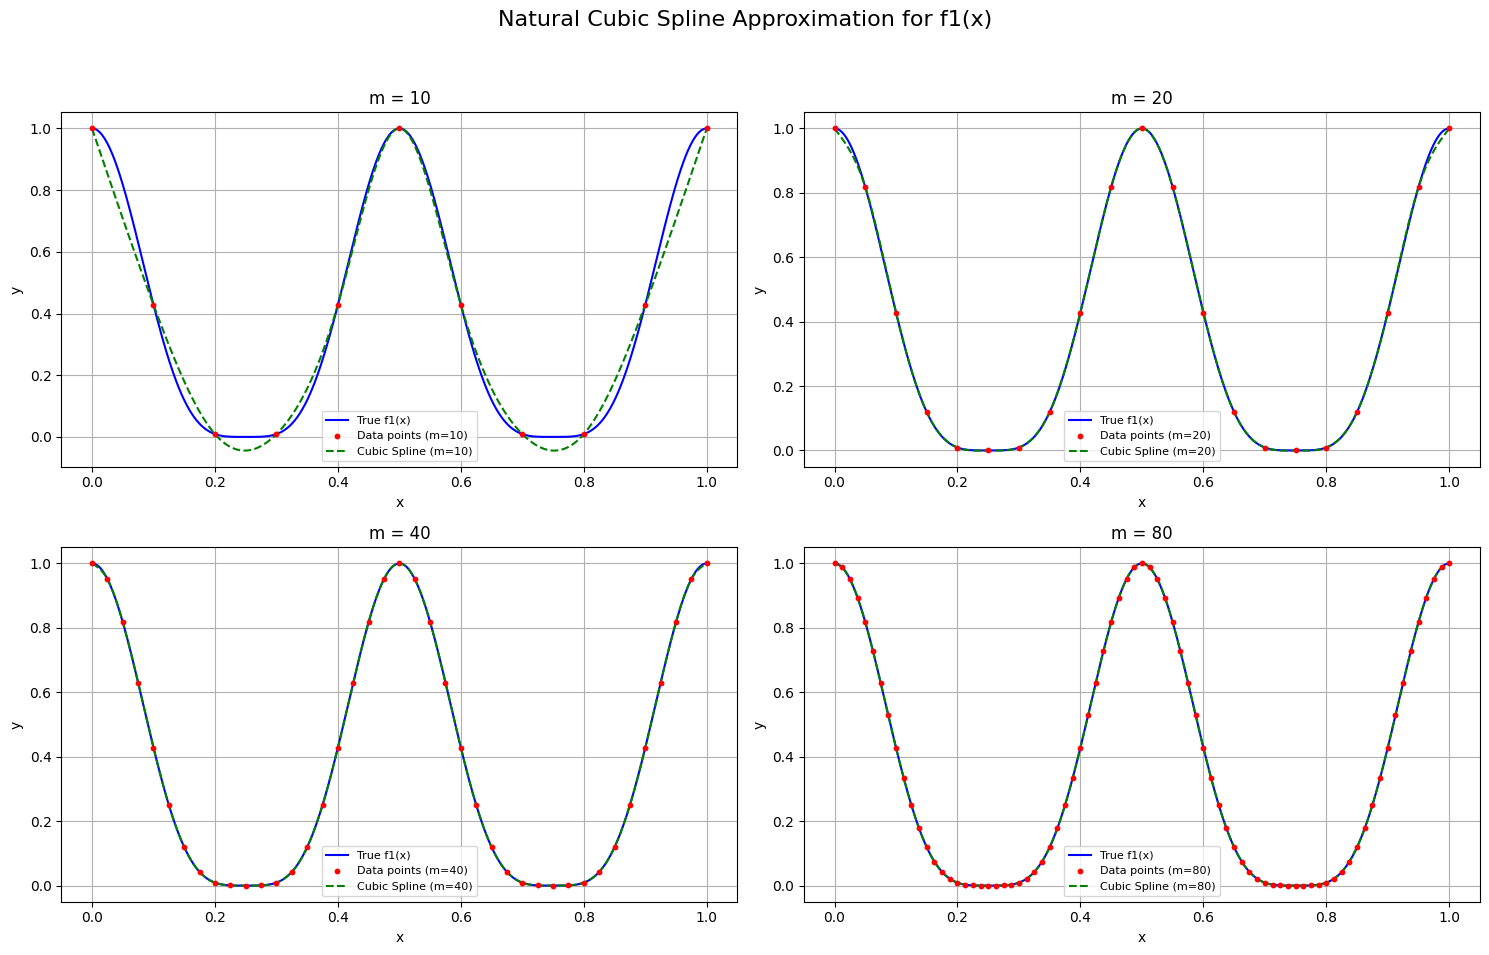

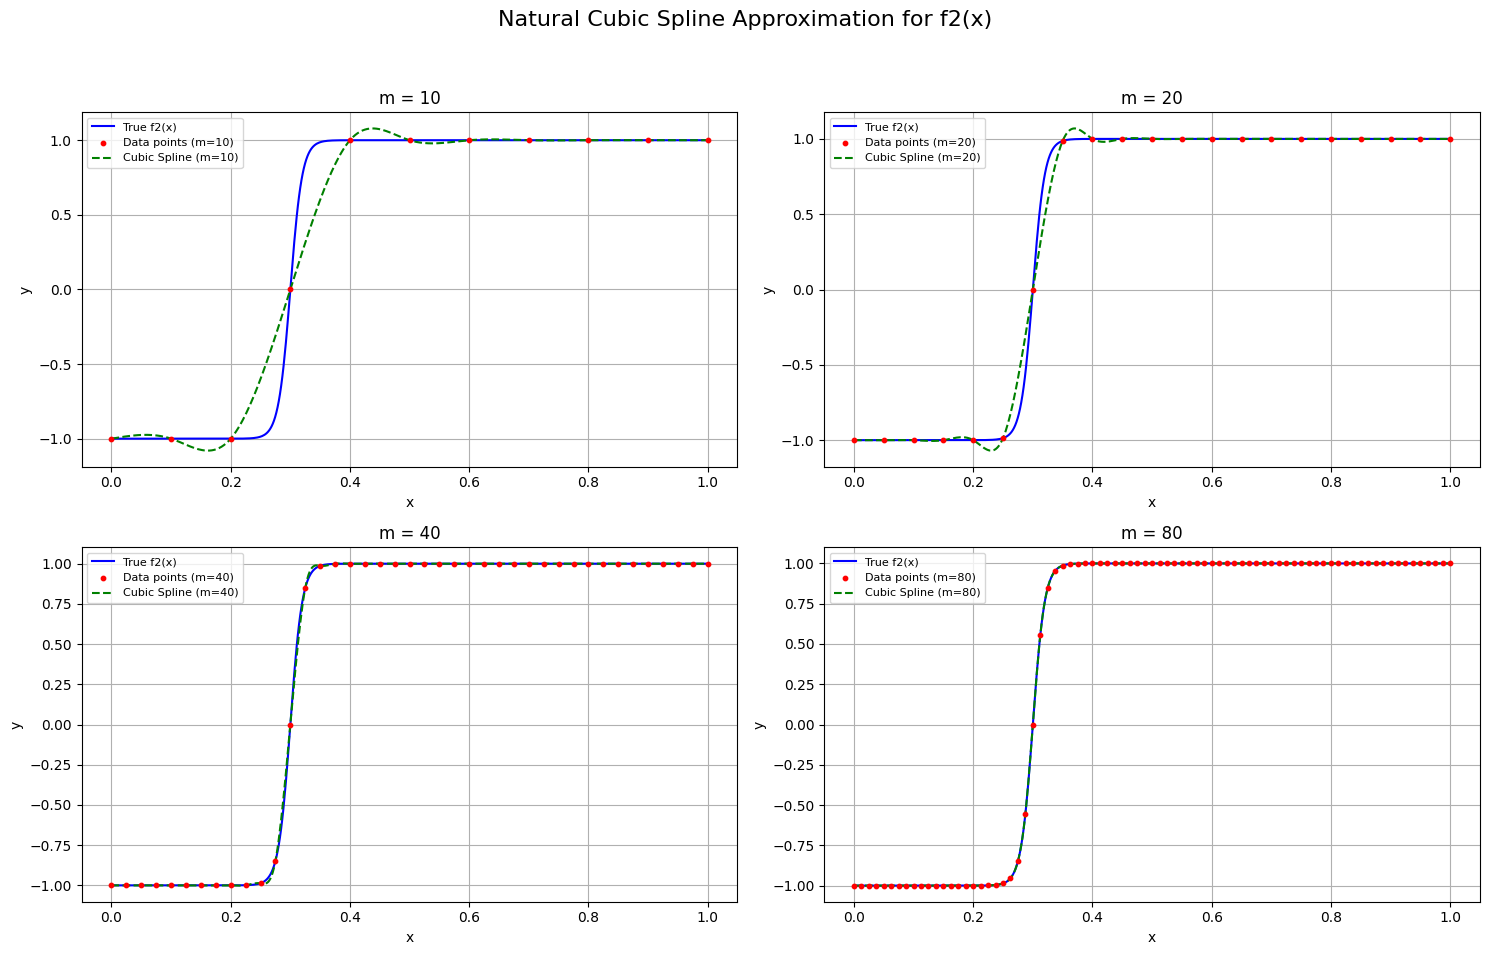

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions f1(x) and f2(x) - copied for self-contained execution if needed, but already defined in kernel
def f1(x):
    return np.cos(2 * np.pi * x)**4

def f2(x):
    return np.tanh(50 * (x - 0.3))

# Define the Hermite basis polynomials - copied for self-contained execution if needed, but already defined in kernel
def H00(t):
    return (1 + 2 * t) * (1 - t)**2

def H01(t):
    return t**2 * (3 - 2 * t)

def H10(t):
    return t * (1 - t)**2

def H11(t):
    return t**2 * (t - 1)

# Assuming solve_slopes and evaluate_spline functions are already defined in the kernel from previous steps.
# If not, they would need to be included here or re-executed.

# --- Main computational and plotting loop ---

m_values = [10, 20, 40, 80]
functions = {'f1': f1, 'f2': f2}

# Finer grid for plotting the true function and spline
x_fine = np.linspace(0, 1, 500)

# Store plots to display later
plots = []

for func_name, func in functions.items():
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Natural Cubic Spline Approximation for {func_name}(x)', fontsize=16)

    for i, m in enumerate(m_values):
        # 1. Generate uniform knots and data
        x_k = np.linspace(0, 1, m + 1)
        y_k = func(x_k)
        h = 1 / m

        # 2. Solve for slopes D_k
        D_k = solve_slopes(y_k, h, m)

        # 3. Evaluate the spline on a finer grid
        s_fine = evaluate_spline(x_fine, x_k, y_k, D_k, h)

        # 4. Plotting
        plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
        plt.plot(x_fine, func(x_fine), label=f'True {func_name}(x)', color='blue')
        plt.scatter(x_k, y_k, label=f'Data points (m={m})', color='red', marker='o', s=10, zorder=5)
        plt.plot(x_fine, s_fine, label=f'Cubic Spline (m={m})', color='green', linestyle='--')
        plt.title(f'm = {m}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(fontsize=8)
        plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()


(b) (Computational) For each function $\{f_\ell\}_{\ell = 1}^2$, compute the clamped cubic spline by prescribing $D_0 = f_\ell'(0)$ and $D_m = f_\ell'(1)$ and using the interior equations for $k = 1, ..., m - 1$. Evaluate the spline as in part (a).

Defining derivatives of functions $f_1$ and $f_2$:

In [17]:
import numpy as np

# Define the first derivative of f1(x)
def f1_prime(x):
    return -8 * np.pi * (np.cos(2 * np.pi * x)**3) * np.sin(2 * np.pi * x)

# Define the first derivative of f2(x)
def f2_prime(x):
    return 50 / (np.cosh(50 * (x - 0.3))**2)

Solving for clamped slopes:

In [18]:
import numpy as np

def solve_clamped_slopes(y_k, h, m, D0_clamped, Dm_clamped):
    # Initialize the (m+1) x (m+1) matrix A and (m+1) vector b
    A = np.zeros((m + 1, m + 1))
    b = np.zeros(m + 1)

    # Apply left clamped boundary condition: D_0 = D0_clamped
    A[0, 0] = 1
    b[0] = D0_clamped

    # Apply interior conditions: D_{k-1} + 4D_k + D_{k+1} = (3/h)(y_{k+1} - y_{k-1}) for k = 1, ..., m-1
    for k in range(1, m):
        A[k, k - 1] = 1
        A[k, k] = 4
        A[k, k + 1] = 1
        b[k] = (3 / h) * (y_k[k + 1] - y_k[k - 1])

    # Apply right clamped boundary condition: D_m = Dm_clamped
    A[m, m] = 1
    b[m] = Dm_clamped

    # Solve the system AD = b for D
    D = np.linalg.solve(A, b)
    return D

Plotting true function and clamped splines:

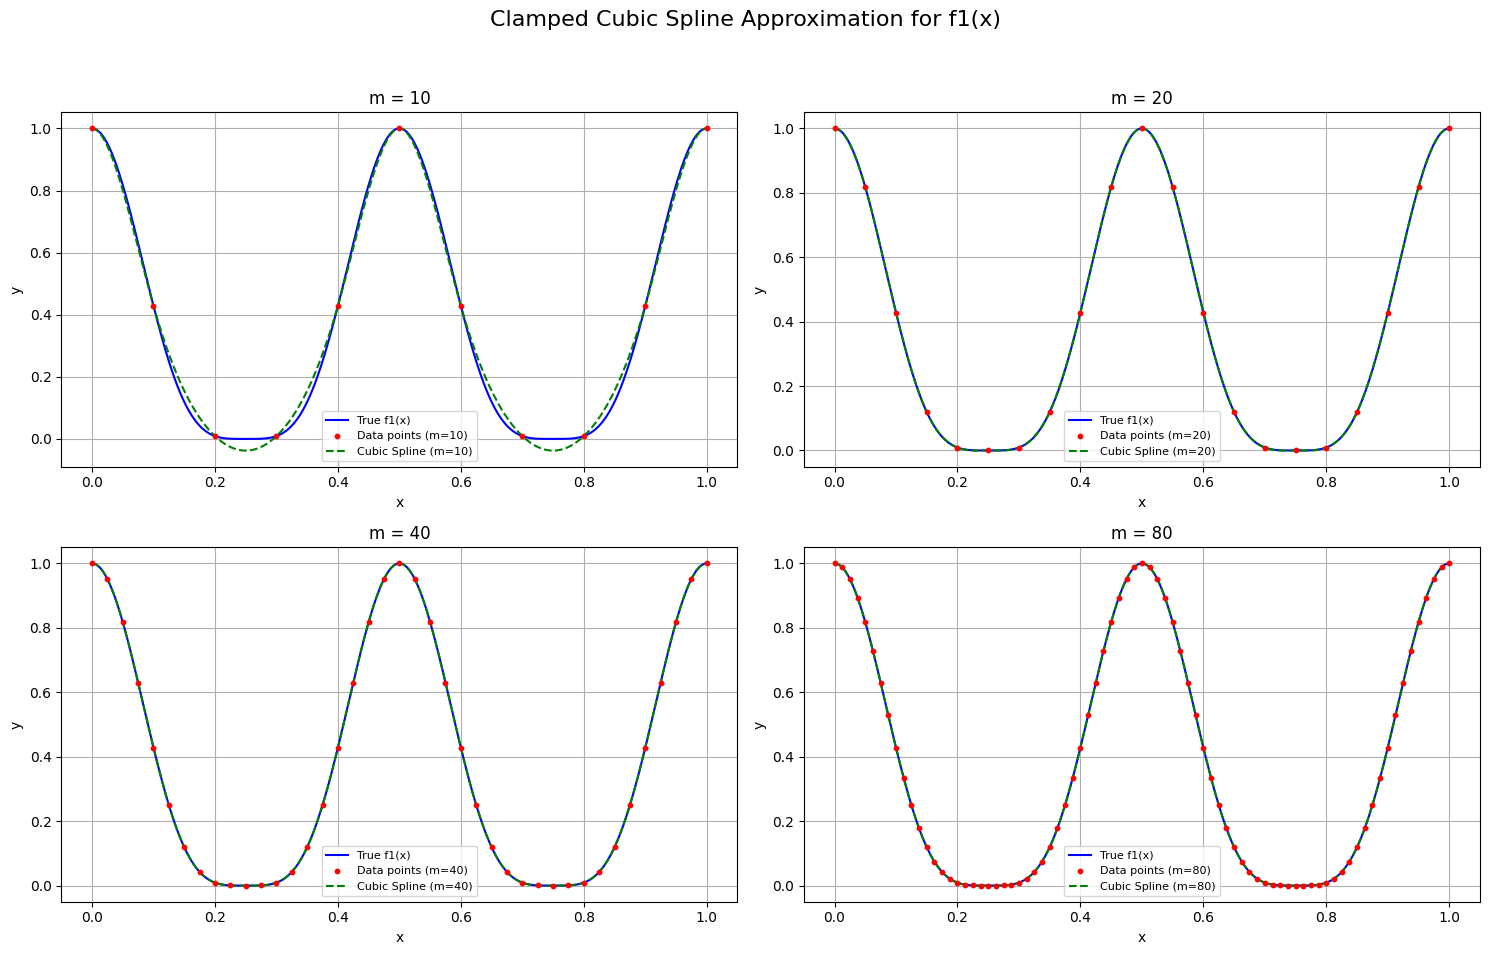

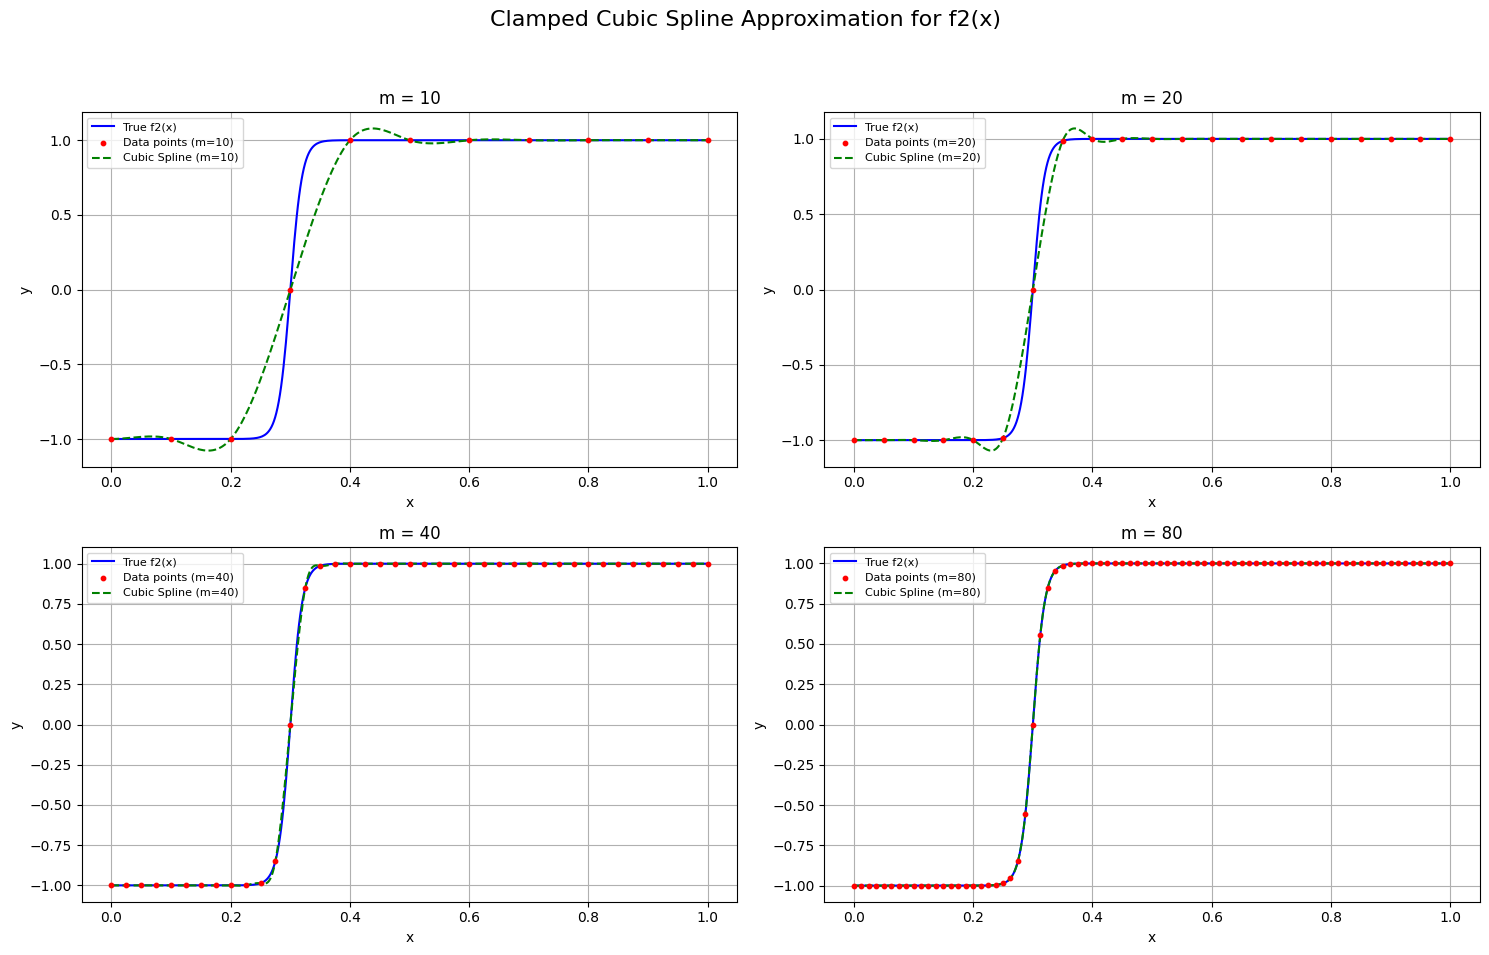

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions f1(x) and f2(x) - copied for self-contained execution if needed
def f1(x):
    return np.cos(2 * np.pi * x)**4

def f2(x):
    return np.tanh(50 * (x - 0.3))

# Define their first derivatives - copied for self-contained execution if needed
def f1_prime(x):
    return -8 * np.pi * (np.cos(2 * np.pi * x)**3) * np.sin(2 * np.pi * x)

def f2_prime(x):
    return 50 / (np.cosh(50 * (x - 0.3))**2)

# Define the Hermite basis polynomials - copied for self-contained execution if needed
def H00(t):
    return (1 + 2 * t) * (1 - t)**2

def H01(t):
    return t**2 * (3 - 2 * t)

def H10(t):
    return t * (1 - t)**2

def H11(t):
    return t**2 * (t - 1)

# Assuming solve_clamped_slopes and evaluate_spline functions are already defined in the kernel from previous steps.
# If not, they would need to be included here or re-executed.
# For a self-contained block, I'll include them here again.

def solve_clamped_slopes(y_k, h, m, D0_clamped, Dm_clamped):
    A = np.zeros((m + 1, m + 1))
    b = np.zeros(m + 1)

    A[0, 0] = 1
    b[0] = D0_clamped

    for k in range(1, m):
        A[k, k - 1] = 1
        A[k, k] = 4
        A[k, k + 1] = 1
        b[k] = (3 / h) * (y_k[k + 1] - y_k[k - 1])

    A[m, m] = 1
    b[m] = Dm_clamped

    D = np.linalg.solve(A, b)
    return D

def evaluate_spline(x_eval, x_k, y_k, D_k, h):
    s_eval = np.zeros_like(x_eval, dtype=float)
    m = len(x_k) - 1 # Number of intervals

    for i, x in enumerate(x_eval):
        # Determine the interval [x_k, x_{k+1}] where x falls
        k = np.searchsorted(x_k, x, side='right') - 1

        # Handle edge case for x = x_m (the last knot)
        if k == m:
            k = m - 1
        elif k < 0:
             k = 0

        t = (x - x_k[k]) / h

        s_eval[i] = y_k[k] * H00(t) + \
                    y_k[k+1] * H01(t) + \
                    h * D_k[k] * H10(t) + \
                    h * D_k[k+1] * H11(t)

    return s_eval

# --- Main computational and plotting loop for clamped splines ---

m_values = [10, 20, 40, 80]
functions_clamped = {'f1': (f1, f1_prime), 'f2': (f2, f2_prime)}

# Finer grid for plotting the true function and spline
x_fine = np.linspace(0, 1, 500)

for func_name, (func, func_prime) in functions_clamped.items():
    plt.figure(figsize=(15, 10))
    plt.suptitle(f'Clamped Cubic Spline Approximation for {func_name}(x)', fontsize=16)

    for i, m in enumerate(m_values):
        # 1. Generate uniform knots and data
        x_k = np.linspace(0, 1, m + 1)
        y_k = func(x_k)
        h = 1 / m

        # 2. Compute clamped boundary derivatives
        D0_clamped = func_prime(0)
        Dm_clamped = func_prime(1)

        # 3. Solve for slopes D_k using clamped boundary conditions
        D_k = solve_clamped_slopes(y_k, h, m, D0_clamped, Dm_clamped)

        # 4. Evaluate the spline on a finer grid
        s_fine = evaluate_spline(x_fine, x_k, y_k, D_k, h)

        # 5. Plotting
        plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
        plt.plot(x_fine, func(x_fine), label=f'True {func_name}(x)', color='blue')
        plt.scatter(x_k, y_k, label=f'Data points (m={m})', color='red', marker='o', s=10, zorder=5)
        plt.plot(x_fine, s_fine, label=f'Cubic Spline (m={m})', color='green', linestyle='--')
        plt.title(f'm = {m}')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.legend(fontsize=8)
        plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

(c) (Interpretation) For each function $\{f_\ell\}_{\ell = 1}^2$, and each $m$, compute and plot $||f_\ell - s||_\infty$ on a fine grid for both boundary conditions. Comment on differences between approximations for the two boundary conditions.

Redefining functions, Hermite polynomials, and derivatives. Calculating $L^\infty$ errors for natural and clamped splines:

In [20]:
import numpy as np

# Re-define functions f1, f2, f1_prime, f2_prime, H00, H01, H10, H11 for self-contained execution
def f1(x):
    return np.cos(2 * np.pi * x)**4

def f2(x):
    return np.tanh(50 * (x - 0.3))

def f1_prime(x):
    return -8 * np.pi * (np.cos(2 * np.pi * x)**3) * np.sin(2 * np.pi * x)

def f2_prime(x):
    return 50 / (np.cosh(50 * (x - 0.3))**2)

def H00(t):
    return (1 + 2 * t) * (1 - t)**2

def H01(t):
    return t**2 * (3 - 2 * t)

def H10(t):
    return t * (1 - t)**2

def H11(t):
    return t**2 * (t - 1)

# Re-define solve_slopes and evaluate_spline functions
def solve_slopes(y_k, h, m):
    A = np.zeros((m + 1, m + 1))
    b = np.zeros(m + 1)

    A[0, 0] = 2
    A[0, 1] = 1
    b[0] = (3 / h) * (y_k[1] - y_k[0])

    for k in range(1, m):
        A[k, k - 1] = 1
        A[k, k] = 4
        A[k, k + 1] = 1
        b[k] = (3 / h) * (y_k[k + 1] - y_k[k - 1])

    A[m, m - 1] = 1
    A[m, m] = 2
    b[m] = (3 / h) * (y_k[m] - y_k[m - 1])

    D = np.linalg.solve(A, b)
    return D

def solve_clamped_slopes(y_k, h, m, D0_clamped, Dm_clamped):
    A = np.zeros((m + 1, m + 1))
    b = np.zeros(m + 1)

    A[0, 0] = 1
    b[0] = D0_clamped

    for k in range(1, m):
        A[k, k - 1] = 1
        A[k, k] = 4
        A[k, k + 1] = 1
        b[k] = (3 / h) * (y_k[k + 1] - y_k[k - 1])

    A[m, m] = 1
    b[m] = Dm_clamped

    D = np.linalg.solve(A, b)
    return D

def evaluate_spline(x_eval, x_k, y_k, D_k, h):
    s_eval = np.zeros_like(x_eval, dtype=float)
    m_intervals = len(x_k) - 1

    for i, x in enumerate(x_eval):
        k = np.searchsorted(x_k, x, side='right') - 1
        if k == m_intervals:
            k = m_intervals - 1
        elif k < 0:
             k = 0

        t = (x - x_k[k]) / h

        s_eval[i] = y_k[k] * H00(t) + \
                    y_k[k+1] * H01(t) + \
                    h * D_k[k] * H10(t) + \
                    h * D_k[k+1] * H11(t)
    return s_eval


# 1. Initialize m_values and functions dictionary
m_values = [10, 20, 40, 80]
functions = {'f1': (f1, f1_prime), 'f2': (f2, f2_prime)}

# 2. Create a fine grid x_fine
x_fine = np.linspace(0, 1, 1000) # Increased resolution for better error calculation

# 3. Initialize errors dictionary
errors = {
    'f1': {'natural': [], 'clamped': []},
    'f2': {'natural': [], 'clamped': []}
}

# 4. Loop through each function
for func_name, (func, func_prime) in functions.items():
    print(f"\n--- Processing {func_name}(x) ---")

    # 5. For each function, loop through each value of m
    for m in m_values:
        print(f"  m = {m}:")

        # 6a. Calculate the step size h
        h = 1 / m
        # 6b. Generate uniform knots x_k
        x_k = np.linspace(0, 1, m + 1)
        # 6c. Evaluate the true function at these knots y_k
        y_k = func(x_k)
        # 6d. Evaluate the true function on the fine grid f_true_fine
        f_true_fine = func(x_fine)

        # 7. For the Natural Cubic Spline:
        # 7a. Call solve_slopes to get D_natural
        D_natural = solve_slopes(y_k, h, m)
        # 7b. Call evaluate_spline to get s_natural_fine
        s_natural_fine = evaluate_spline(x_fine, x_k, y_k, D_natural, h)
        # 7c. Calculate the L_inf error for the natural spline
        L_inf_natural = np.max(np.abs(f_true_fine - s_natural_fine))
        # 7d. Append L_inf_natural and print its value
        errors[func_name]['natural'].append(L_inf_natural)
        print(f"    Natural L_inf: {L_inf_natural:.8f}")

        # 8. For the Clamped Cubic Spline:
        # 8a. Compute D0_clamped and Dm_clamped
        D0_clamped = func_prime(0)
        Dm_clamped = func_prime(1)
        # 8b. Call solve_clamped_slopes to get D_clamped
        D_clamped = solve_clamped_slopes(y_k, h, m, D0_clamped, Dm_clamped)
        # 8c. Call evaluate_spline to get s_clamped_fine
        s_clamped_fine = evaluate_spline(x_fine, x_k, y_k, D_clamped, h)
        # 8d. Calculate the L_inf error for the clamped spline
        L_inf_clamped = np.max(np.abs(f_true_fine - s_clamped_fine))
        # 8e. Append L_inf_clamped and print its value
        errors[func_name]['clamped'].append(L_inf_clamped)
        print(f"    Clamped L_inf: {L_inf_clamped:.8f}")


--- Processing f1(x) ---
  m = 10:
    Natural L_inf: 0.11435380
    Clamped L_inf: 0.03766449
  m = 20:
    Natural L_inf: 0.02202194
    Clamped L_inf: 0.00117622
  m = 40:
    Natural L_inf: 0.00499590
    Clamped L_inf: 0.00006601
  m = 80:
    Natural L_inf: 0.00121871
    Clamped L_inf: 0.00000399

--- Processing f2(x) ---
  m = 10:
    Natural L_inf: 0.53727871
    Clamped L_inf: 0.53688661
  m = 20:
    Natural L_inf: 0.28033858
    Clamped L_inf: 0.28033838
  m = 40:
    Natural L_inf: 0.06301649
    Clamped L_inf: 0.06301649
  m = 80:
    Natural L_inf: 0.00378247
    Clamped L_inf: 0.00378247


Plotting $L^\infty$ Errors:


Generating plots...


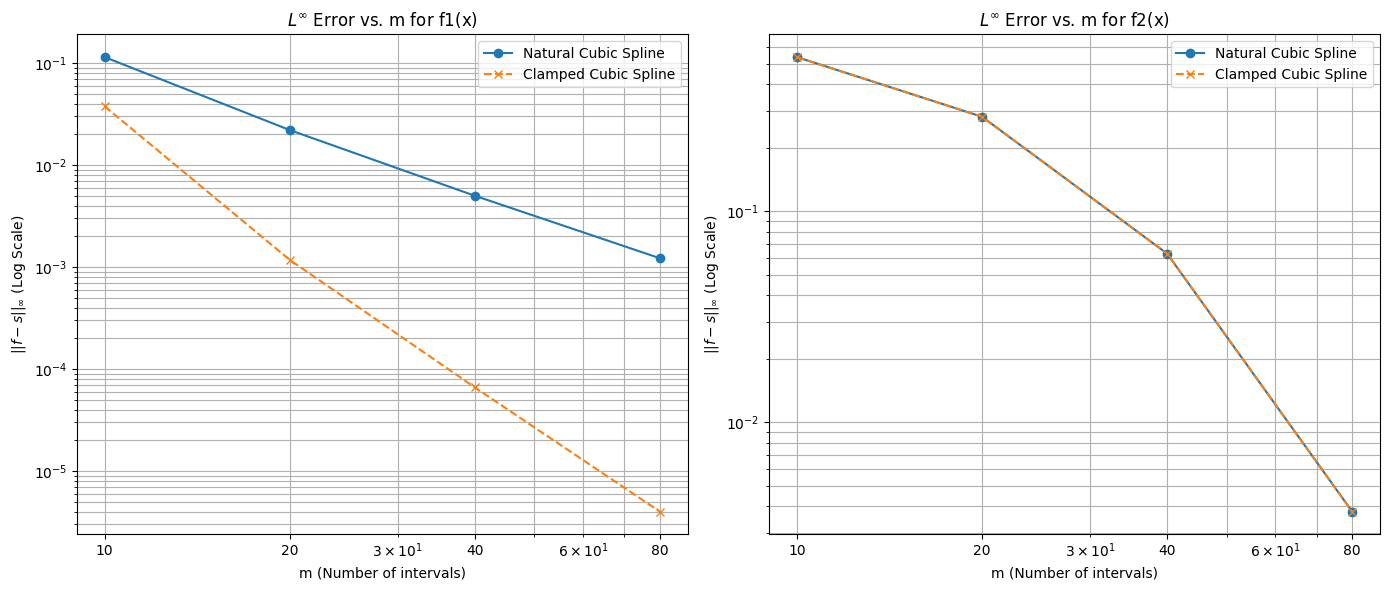

In [38]:
import matplotlib.pyplot as plt

# --- Plot L-infinity Errors ---

print("\nGenerating plots...")
plt.figure(figsize=(14, 6))

for i, (func_name, _) in enumerate(functions.items()):
    plt.subplot(1, 2, i + 1)
    plt.loglog(m_values, errors[func_name]['natural'], '-o', label='Natural Cubic Spline')
    plt.loglog(m_values, errors[func_name]['clamped'], '--x', label='Clamped Cubic Spline')
    plt.title(f'$L^\\infty$ Error vs. m for {func_name}(x)')
    plt.xlabel('m (Number of intervals)')
    plt.ylabel('$||f - s||_\\infty$ (Log Scale)')
    plt.xticks(m_values, labels=[str(m) for m in m_values])
    plt.grid(True, which="both", ls="-")
    plt.legend()

plt.tight_layout()
plt.show()


For the function $f_1$, the clamped cubic splines performed better than the natural cubic splines, resulting in smaller errors in the infinity norm over all intervals. However for the function $f_2$, both methods performed the same, resulting in identical errors over all intervals.

<div style="page-break-after: always;"></div>

# **Exercise 1.5** (Bsplines (Cox-de Boor construction): basis properties and sparse algebra).
Fix degree $p = 3$ and an open knot vector on $[0, 1]$ with $K = 8$ uniform interior knots.

(a) (Computational) Implement the Cox-de Boor recursion for $B_{i,p}(x)$ and plot all cubic B-splines basis functions on $[0, 1]$, using the following process:

**Step 0: build an open uniform knot vector.** Let $p = 3$ and $K = 8$ interior knots. Use the open knot vector
$$t = (\underbrace{0, ..., 0}_{p+1 \text{ times}}, \frac{1}{K+1}, \frac{2}{K+1}, ..., \frac{K}{K+1}, \underbrace{1, ..., 1}_{p+1 \text{ times}}).$$
Let $N = length(t) - p - 1$; then there are N cubic B-splines $B_{0,3}, ..., B_{N-1,3}$.

**Step 1: base case (p = 0)**. Define
$$B_{i,0}(x) =
\begin{cases}
  1 & , t_i \le x \le t_{i+1} \\
  0 & , \text{otherwise}
\end{cases}$$
(with the convention $B_{N-1, 0}(1) = 1$ so the last basis function includes the right endpoint).

**Step 2: recursion ($p \ge 1$)**. For $p \ge 1$, define
$$B_{i,p}(x) = \alpha_{i,p}(x) B_{i,p-1}(x) + \beta_{i,p}(x) B_{i+1,p-1}(x)$$
where
$$\alpha_{i,p}(x) =
\begin{cases}
  \frac{x - t_i}{t_{i+p} - t_i}, & t_{i+p} \neq t_i \\
  0, & t_{i+p} = t_i
\end{cases}
\quad
\beta_{i,p}(x) =
\begin{cases}
  \frac{t_{i+p+1} - x}{t_{i+p+1} - t_{i+1}}, & t_{i+p+1} \neq t_{i+1} \\
  0, & t_{i+p+1} = t_{i+1}
\end{cases}$$
Implement this recursion and plot all $B_i,3}(x)$ on a fine grid in $[0, 1]$.

Defining variables and building the knot vector:

In [22]:
import numpy as np

p = 3  # Degree of the B-spline
K = 8  # Number of interior knots

# Construct the open uniform knot vector
zeros_segment = np.zeros(p + 1)
interior_knots = np.linspace(1 / (K + 1), K / (K + 1), K)
ones_segment = np.ones(p + 1)

t = np.concatenate((zeros_segment, interior_knots, ones_segment))

# Calculate N, the number of cubic B-splines
N = len(t) - p - 1

print(f"Degree p: {p}")
print(f"Number of interior knots K: {K}")
print(f"Knot vector t: {t}")
print(f"Number of B-splines N: {N}")

Degree p: 3
Number of interior knots K: 8
Knot vector t: [0.         0.         0.         0.         0.11111111 0.22222222
 0.33333333 0.44444444 0.55555556 0.66666667 0.77777778 0.88888889
 1.         1.         1.         1.        ]
Number of B-splines N: 12


Defining the B-spline basis function base case:

In [23]:
def B_0(x, i, t):
    # B_i,0(x) = 1 if t_i <= x < t_{i+1}, else 0
    # Special handling for the last interval where x <= t_{i+1}
    if t[i] <= x < t[i+1]:
        return 1.0
    elif i == N - 1 and x == t[i+1]: # Convention B_{N-1,0}(1) = 1 for the last basis function
        return 1.0
    else:
        return 0.0

Defining recursive B-spline function recursive step:

In [24]:
def B(x, i, p, t):
    if p == 0:
        return B_0(x, i, t)

    alpha_num = x - t[i]
    alpha_den = t[i+p] - t[i]
    alpha = alpha_num / alpha_den if alpha_den != 0 else 0.0

    beta_num = t[i+p+1] - x
    beta_den = t[i+p+1] - t[i+1]
    beta = beta_num / beta_den if beta_den != 0 else 0.0

    return alpha * B(x, i, p-1, t) + beta * B(x, i+1, p-1, t)

Plotting cubic B-spline basis functions:

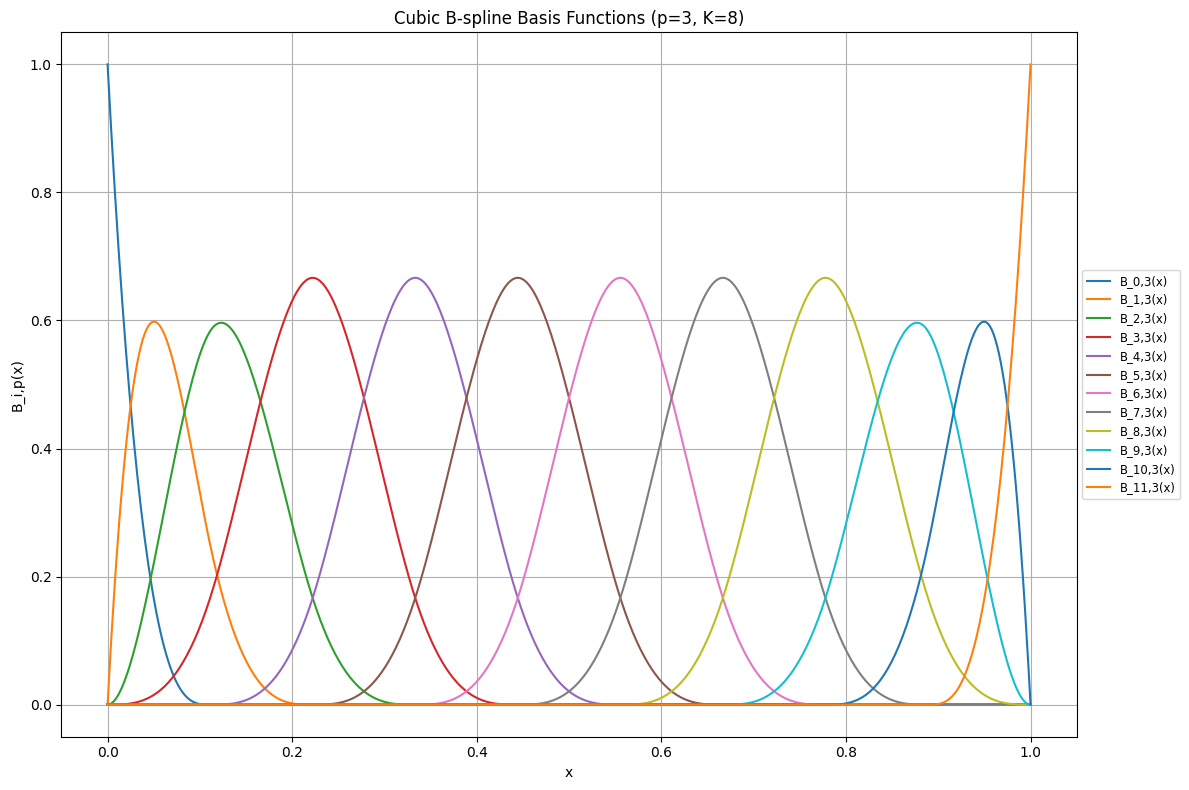

In [25]:
import matplotlib.pyplot as plt

# Create a fine grid for plotting
x_fine = np.linspace(0, 1, 500)

plt.figure(figsize=(12, 8))

# Plot all B_i,3(x) basis functions
for i in range(N):
    y_values = [B(x, i, p, t) for x in x_fine]
    plt.plot(x_fine, y_values, label=f'B_{i},{p}(x)')

plt.title(f'Cubic B-spline Basis Functions (p={p}, K={K})')
plt.xlabel('x')
plt.ylabel('B_i,p(x)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')
plt.grid(True)
plt.tight_layout()
plt.show()

(b) **(Computational + Interpretation: fitting and noise sensitivity)** Let $m = 100$ and $x_k = k/m$. Build the collocation matrix $A_{k,i} = B_{i,3}(x_k)$ (with $p = 3, K = 8$ and the open knot vector from part (a)). Note that $N = length(t) - p - 1 = 12$, so there are 12 basis functions.

(i) **(Fix the noise pattern once)** Set a fixed random seed and generate a single standard normal noise vector $\eta_k \sim N(0, 1)$ for $k = 0, ..., m$. For each noise level $\sigma \in \{0.01, 0.05, 0.10, 0.50\}$ define
$$y_k = f(x_k) + \sigma \eta_k, \quad f(x) = \cos(6\pi x)$$
This makes the comparison across $\sigma$ fair: same noise shape, just scaled)

(ii) **(Least squares fit)** For each $\sigma$, compute the least-squares coefficients
$$c_{t,S} = \arg \min_c ||Ac - y||_2$$
and form the fitted spline $s_{t, S}(x) = \sum_t c_{t,S,i}B_{i,3}(x)$

(iii) **(Square / interpolation-like fit, if possible)** Choose exactly $N = 12$ data sites (e.g. N evenly spaced indices from $\{0, ..., m\}), form the square matrix $A_{sq}$ and vector $y_{sq}$ using those sites, and solve
$$A_{sq}c_{sq} = y_{sq}$$
if the system is nonsingular / well-conditioned. Otherwise, skip this solve and briefly note why (e.g. ill-conditioning)

(iv) **(Report + compare)** For each $\sigma$ and each method you computed, report
$$\text{misfit } ||Ac - y||_2, \quad \text{max error } E_\infty = \max_{x \in \text{fine grid}} |f(x) - s(x)|$$
Also make plots (one figure with 4 subplots is fine): on a fine grid, plot $f$, the noisy data, and the two fitted splines

(v) **(Sparsity observation)** Compute how many nonzeros appear in a typical row of $A$ (e.g. the max/average of nnz per row), and explain in 1-2 sentences how local support of B-splines implies $A$ is banded/sparse. Finally, comment on which fit looks more stable as $\sigma$ increases and why.

(i) **(Fix the noise pattern once)**

Defining parameters and noise generation:

In [26]:
import numpy as np

# 1. Define m
m = 100

# 2. Define the target function f(x)
def f(x):
    return np.cos(6 * np.pi * x)

# 3. Generate data sites x_k
x_k = np.linspace(0, 1, m + 1)

# 4. Set the random seed
np.random.seed(42)

# 5. Generate a standard normal noise vector eta_k
eta_k = np.random.normal(0, 1, m + 1)

# 6. Define noise levels
sigma_levels = [0.01, 0.05, 0.10, 0.50]

print(f"Defined m: {m}")
print(f"Generated {len(x_k)} data sites x_k from 0 to 1.")
print(f"Generated a noise vector eta_k of length {len(eta_k)}.")
print(f"Defined sigma levels: {sigma_levels}")

Defined m: 100
Generated 101 data sites x_k from 0 to 1.
Generated a noise vector eta_k of length 101.
Defined sigma levels: [0.01, 0.05, 0.1, 0.5]


Constructing collocation matrix $A$

In [27]:
import numpy as np

# --- Parameters from part (a) (already available in kernel state) ---
# p = 3  # Degree of the B-spline
# K = 8  # Number of interior knots
# t = np.concatenate((np.zeros(p + 1), np.linspace(1 / (K + 1), K / (K + 1), K), np.ones(p + 1)))
# N = len(t) - p - 1 # N = 12

# --- Assume B_0 and B functions are defined in the kernel from previous steps ---
# If not, they would need to be re-included for a self-contained block.
# For this step, we assume they are accessible.

# --- Build Collocation Matrix A ---
# A_k,i = B_i,3(x_k)
# A will have dimensions (m+1) x N, where N is the number of basis functions (12)
A = np.zeros((m + 1, N))
for k_idx in range(m + 1):
    for i_idx in range(N):
        A[k_idx, i_idx] = B(x_k[k_idx], i_idx, p, t)

print(f"Collocation matrix A shape: {A.shape}")

Collocation matrix A shape: (101, 12)


Defining utility function:

In [28]:
import numpy as np

def evaluate_fitted_spline(x_eval, coefficients, B_func, p, t, N_basis):
    """
    Evaluates the fitted B-spline s(x) = sum(c_i * B_i,p(x)) on a fine grid.
    """
    s_eval = np.zeros_like(x_eval)
    for idx_x, x_val in enumerate(x_eval):
        for i in range(N_basis):
            s_eval[idx_x] += coefficients[i] * B_func(x_val, i, p, t)
    return s_eval

(ii) **(Least squares fit)**

(iii) **(Square / interpolation-like fit, if possible)**

(iv) **(Report + compare)**

Least-squares fit and interpolation-like fit:


--- Processing for sigma = 0.01 ---
  Least Squares Fit:
    Misfit ||Ac - y||_2: 0.388484
    Max Error E_inf: 0.070432
  Square/Interpolation-like Fit:
    Misfit ||A_sq c_sq - y_sq||_2: 0.000000
    Max Error E_inf: 0.306506

--- Processing for sigma = 0.05 ---
  Least Squares Fit:
    Misfit ||Ac - y||_2: 0.555793
    Max Error E_inf: 0.081597
  Square/Interpolation-like Fit:
    Misfit ||A_sq c_sq - y_sq||_2: 0.000000
    Max Error E_inf: 0.474932

--- Processing for sigma = 0.1 ---
  Least Squares Fit:
    Misfit ||Ac - y||_2: 0.914949
    Max Error E_inf: 0.118665
  Square/Interpolation-like Fit:
    Misfit ||A_sq c_sq - y_sq||_2: 0.000000
    Max Error E_inf: 0.686806

--- Processing for sigma = 0.5 ---
  Least Squares Fit:
    Misfit ||Ac - y||_2: 4.277001
    Max Error E_inf: 0.415210
  Square/Interpolation-like Fit:
    Misfit ||A_sq c_sq - y_sq||_2: 0.000000
    Max Error E_inf: 2.387014


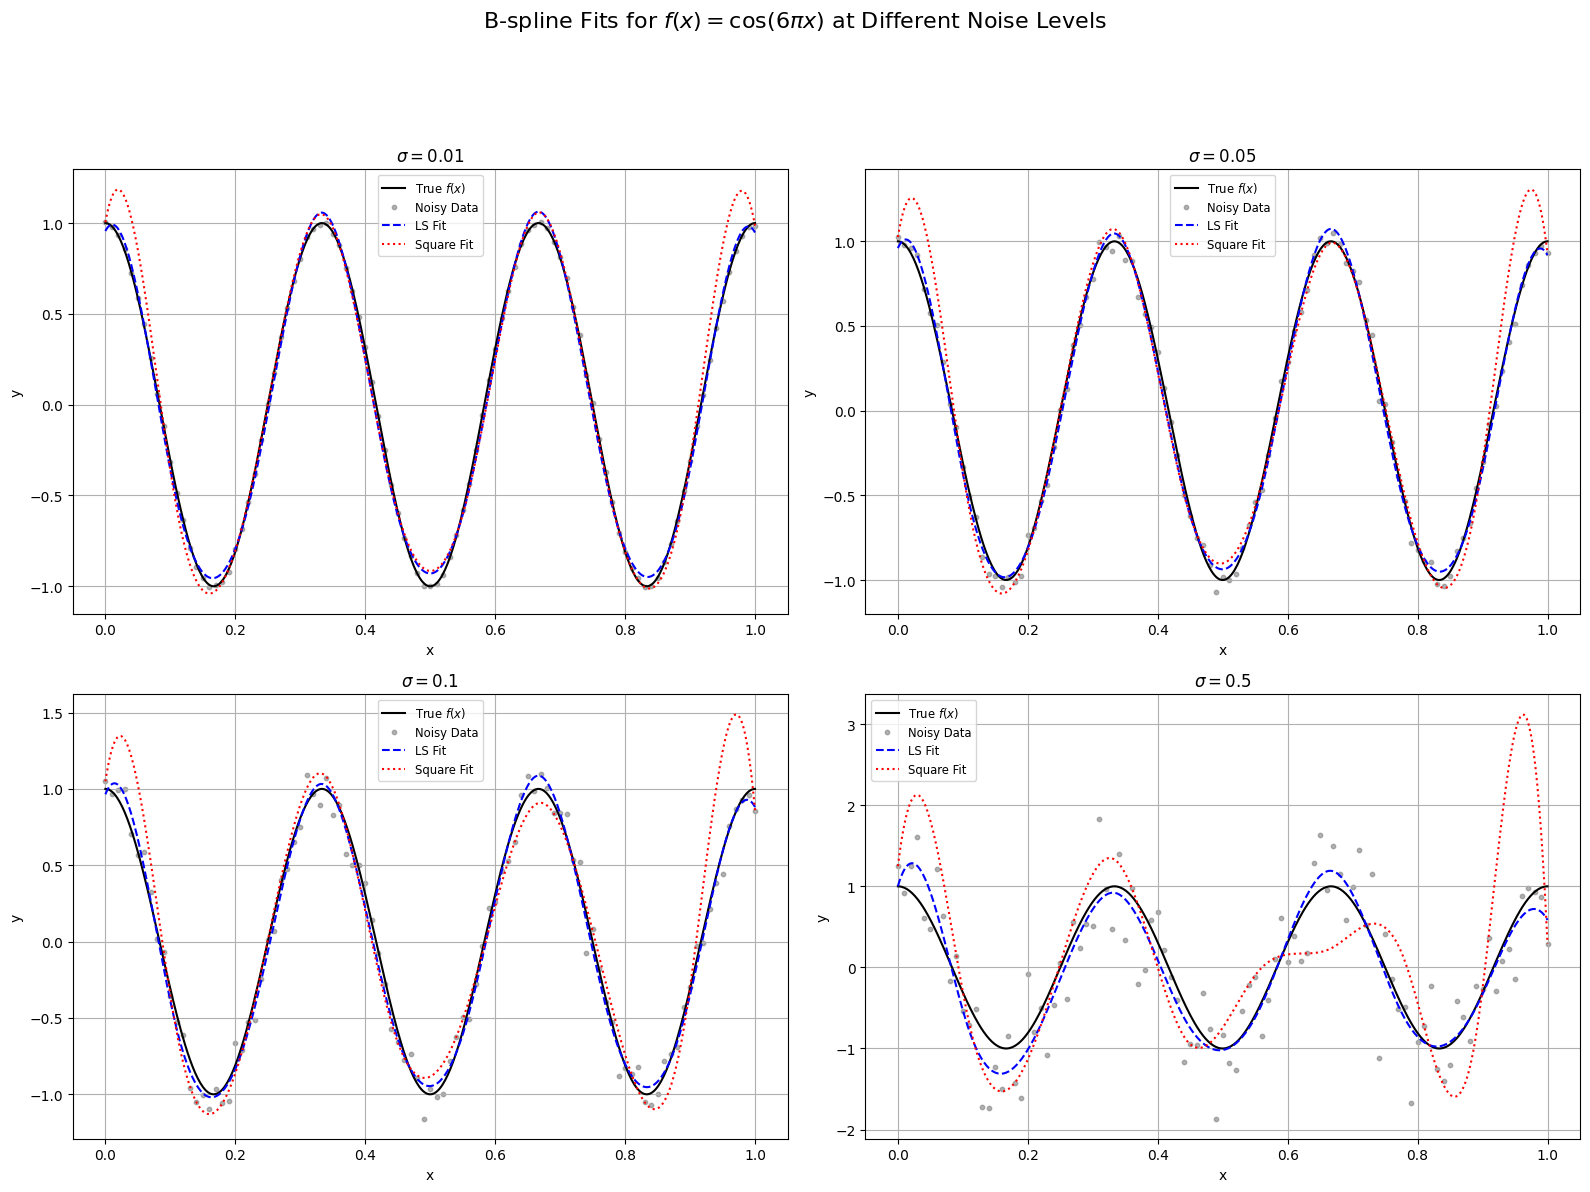


--- Summary of Results ---
Sigma    | Method          | Misfit          | Max Error (E_inf) | Status         
---------------------------------------------------------------------------
0.01     | Least Squares   | 0.388484        | 0.070432        | Computed       
         | Square/Interp.  | 0.000000        | 0.306506        | Computed       
0.05     | Least Squares   | 0.555793        | 0.081597        | Computed       
         | Square/Interp.  | 0.000000        | 0.474932        | Computed       
0.10     | Least Squares   | 0.914949        | 0.118665        | Computed       
         | Square/Interp.  | 0.000000        | 0.686806        | Computed       
0.50     | Least Squares   | 4.277001        | 0.415210        | Computed       
         | Square/Interp.  | 0.000000        | 2.387014        | Computed       


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Fine grid for evaluation and plotting
x_fine = np.linspace(0, 1, 500)
f_true_fine = f(x_fine)

# Prepare for plotting multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Flatten to easily iterate

all_results = {}

for s_idx, sigma in enumerate(sigma_levels):
    print(f"\n--- Processing for sigma = {sigma} ---")
    current_results = {'sigma': sigma}

    # (i) Generate noisy observations y_k
    y_k = f(x_k) + sigma * eta_k

    # (ii) Least Squares Fit
    # np.linalg.lstsq returns (coefficients, residuals, rank, singular_values)
    c_ls, residuals, rank, s_vals = np.linalg.lstsq(A, y_k, rcond=None)
    s_ls_fine = evaluate_fitted_spline(x_fine, c_ls, B, p, t, N)

    # Calculate misfit and max error for LS fit
    misfit_ls = np.linalg.norm(np.dot(A, c_ls) - y_k, 2)
    E_inf_ls = np.max(np.abs(f_true_fine - s_ls_fine))
    current_results['LS'] = {'misfit': misfit_ls, 'E_inf': E_inf_ls, 'coefficients': c_ls.tolist()} # Convert to list for JSON compatibility
    print(f"  Least Squares Fit:")
    print(f"    Misfit ||Ac - y||_2: {misfit_ls:.6f}")
    print(f"    Max Error E_inf: {E_inf_ls:.6f}")

    # (iii) Square/Interpolation-like Fit
    s_sq_fine = None # Initialize to None in case it's skipped
    try:
        # Choose N evenly spaced data sites from x_k
        indices_sq = np.linspace(0, m, N, dtype=int)
        x_sq = x_k[indices_sq]
        y_sq = y_k[indices_sq]

        A_sq = np.zeros((N, N))
        for k_idx_sq in range(N):
            for i_idx_sq in range(N):
                A_sq[k_idx_sq, i_idx_sq] = B(x_sq[k_idx_sq], i_idx_sq, p, t)

        # Check for condition number to identify ill-conditioning
        cond_num = np.linalg.cond(A_sq)
        if cond_num > 1e10: # Heuristic threshold for ill-conditioning
            print(f"  Square/Interpolation-like Fit: Skipped due to ill-conditioning (Condition Number: {cond_num:.2e})")
            current_results['Square'] = {'status': 'skipped', 'reason': f'Ill-conditioned A_sq (cond={cond_num:.2e})'}
        else:
            c_sq = np.linalg.solve(A_sq, y_sq)
            s_sq_fine = evaluate_fitted_spline(x_fine, c_sq, B, p, t, N)

            # Calculate misfit and max error for Square fit
            misfit_sq = np.linalg.norm(np.dot(A_sq, c_sq) - y_sq, 2)
            E_inf_sq = np.max(np.abs(f_true_fine - s_sq_fine))
            current_results['Square'] = {'misfit': misfit_sq, 'E_inf': E_inf_sq, 'coefficients': c_sq.tolist(), 'status': 'computed'}
            print(f"  Square/Interpolation-like Fit:")
            print(f"    Misfit ||A_sq c_sq - y_sq||_2: {misfit_sq:.6f}")
            print(f"    Max Error E_inf: {E_inf_sq:.6f}")

    except np.linalg.LinAlgError as e:
        print(f"  Square/Interpolation-like Fit: Skipped due to {e}")
        current_results['Square'] = {'status': 'skipped', 'reason': str(e)}

    all_results[sigma] = current_results

    # (iv) Plotting
    ax = axes[s_idx]
    ax.plot(x_fine, f_true_fine, 'k-', label='True $f(x)$')
    ax.scatter(x_k, y_k, s=10, alpha=0.6, color='gray', label='Noisy Data')
    ax.plot(x_fine, s_ls_fine, 'b--', label='LS Fit')
    if s_sq_fine is not None:
        ax.plot(x_fine, s_sq_fine, 'r:', label='Square Fit')
    ax.set_title(f'$\\sigma = {sigma}$')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize='small')
    ax.grid(True)

plt.suptitle('B-spline Fits for $f(x) = \\cos(6\\pi x)$ at Different Noise Levels', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Summarize all results in a table-like format ---
print("\n--- Summary of Results ---")
print("{:<8} | {:<15} | {:<15} | {:<15} | {:<15}".format("Sigma", "Method", "Misfit", "Max Error (E_inf)", "Status"))
print("-" * 75)
for sigma, res in all_results.items():
    ls_res = res['LS']
    print("{:<8.2f} | {:<15} | {:<15.6f} | {:<15.6f} | {:<15}".format(
        sigma, "Least Squares", ls_res['misfit'], ls_res['E_inf'], "Computed"
    ))
    sq_res = res['Square']
    if sq_res['status'] == 'computed':
        print("{:<8} | {:<15} | {:<15.6f} | {:<15.6f} | {:<15}".format(
            "", "Square/Interp.", sq_res['misfit'], sq_res['E_inf'], "Computed"
        ))
    else:
        print("{:<8} | {:<15} | {:<15} | {:<15} | {:<15}".format(
            "", "Square/Interp.", "N/A", "N/A", sq_res['reason']
        ))


(v) **(Sparsity observation)**

Calculating average nonzeroes per row:

In [30]:
non_zeros_per_row = np.sum(A != 0, axis=1)
avg_nnz_per_row = np.mean(non_zeros_per_row)
max_nnz_per_row = np.max(non_zeros_per_row)
print(f"\n--- Sparsity Analysis ---")
print(f"Average non-zeros per row in Collocation Matrix A: {avg_nnz_per_row:.2f}")
print(f"Maximum non-zeros per row in Collocation Matrix A: {max_nnz_per_row}")


--- Sparsity Analysis ---
Average non-zeros per row in Collocation Matrix A: 3.94
Maximum non-zeros per row in Collocation Matrix A: 4


For cubic splines, locally supported B-splines overlap with at most 3 neighbors with nonzeroes lieing near the diagonal, making the system sparse and banded. Even though Least Squares has a large misfit value, it has a small max error value, making it more stable. This is to be expected, as the interpolation-like fit tries to minimize the misfit, but in turn, the max error grows exponentially as $\sigma$ increases.

<div style="page-break-after: always;"></div>

# **Exercise 1.6** (Extension of B-Splines Exercise: smoothing splines and regularization (fit vs. roughness))

This exercise is a direct extension of the previous B-spline fitting exercise. You should resuse your code that: (i) builds the open knot vector, (ii) evaluates cubic B-splines via Cox-de-Boor, and (iii) assembles the collocation matrix $A_{k,j} = B_{j,3}(x_k)$ and evaluates $s(x) = \sum_j c_j B_{j,3}(x)$. The only new ingredient is a roughness penalty based on second derivatives.

Let $f(x) = \exp(-x^2)$ on $[0, 1]$. Take $m = 200$ uniformly spaced sites $x_k = k/m$ and noisy data $y_k = f(x_k) + \eta_k$ with $\eta_k \sim N(0, \sigma^2), \sigma = 0.1$ (fixed seed).

Choose a cubic B-spline space (degree $p = 3$) with an open knot vector having $K = 15$ interior knots.

(a) (Computational) Assemble $A$ as before. Then build an approximation to the roughness matrix
$$R_{ij} = \int_0^1 B_{i,3}''(x) B_{j,3}''(x) dx$$
using numerical quadrature (e.g., trapezoidal rule) on a dense uniform grid (e.g., composite trapezoid). For each $\lambda \in \{10^{-6}, 10^{-4}, 10^{-2}, 10^0\}$, solve the regularized normal equations
$$A^T A + \lambda R)c = A^T y$$
(using any method) and plot the resulting fits $s_\lambda (x) = \sum_j c_j B_{j,3}(x)$

Defining parameters, target function, and knot vector:

In [31]:
import numpy as np

# 1. Define the target function f(x)
def f(x):
    return np.exp(-x**2)

# 2. Set data parameters
m = 200  # Number of data sites
sigma = 0.1 # Noise standard deviation

# 3. Generate uniformly spaced data sites
x_k = np.linspace(0, 1, m + 1)

# 4. Set a fixed random seed
np.random.seed(42)

# 5. Generate noisy observations
eta_k = np.random.normal(0, sigma, m + 1)
y_k = f(x_k) + eta_k

# 6. Define B-spline degree and number of interior knots
p = 3  # Degree of the B-spline
K = 15 # Number of interior knots

# 7. Construct the open uniform knot vector
zeros_segment = np.zeros(p + 1)
interior_knots = np.linspace(1 / (K + 1), K / (K + 1), K)
ones_segment = np.ones(p + 1)

t = np.concatenate((zeros_segment, interior_knots, ones_segment))

# 8. Calculate the number of B-spline basis functions
N = len(t) - p - 1

print(f"Target function f(x) = exp(-x**2) defined.")
print(f"Number of data sites (m): {m}")
print(f"Noise standard deviation (sigma): {sigma}")
print(f"Generated {len(x_k)} data sites x_k.")
print(f"Generated {len(y_k)} noisy observations y_k.")
print(f"B-spline degree (p): {p}")
print(f"Number of interior knots (K): {K}")
print(f"Knot vector t: {t}")
print(f"Number of B-spline basis functions (N): {N}")

Target function f(x) = exp(-x**2) defined.
Number of data sites (m): 200
Noise standard deviation (sigma): 0.1
Generated 201 data sites x_k.
Generated 201 noisy observations y_k.
B-spline degree (p): 3
Number of interior knots (K): 15
Knot vector t: [0.     0.     0.     0.     0.0625 0.125  0.1875 0.25   0.3125 0.375
 0.4375 0.5    0.5625 0.625  0.6875 0.75   0.8125 0.875  0.9375 1.
 1.     1.     1.    ]
Number of B-spline basis functions (N): 19


Building collocation matrix $A$:

In [32]:
import numpy as np

# Create an empty NumPy array A with dimensions (m + 1) rows and N columns, initialized with zeros.
A = np.zeros((m + 1, N))

# Iterate through each data point x_k and each B-spline basis function index i.
for k_idx in range(m + 1):
    for i_idx in range(N):
        # Compute the value of the B-spline basis function B(x_k[k_idx], i_idx, p, t)
        # and assign it to the corresponding element A[k_idx, i_idx].
        A[k_idx, i_idx] = B(x_k[k_idx], i_idx, p, t)

print(f"Collocation matrix A assembled with shape: {A.shape}")

Collocation matrix A assembled with shape: (201, 19)


Defining the second derivative of $B$:

In [33]:
import numpy as np

def B_double_prime(x_val, i, p_deg, t_vec, delta=1e-5):
    """
    Approximates the second derivative B_i,p''(x_val) using a central finite difference method.
    """
    # Ensure evaluation points are within the domain [0, 1]
    x_plus_delta = np.clip(x_val + delta, 0.0, 1.0)
    x_minus_delta = np.clip(x_val - delta, 0.0, 1.0)

    # Central finite difference formula for the second derivative
    # f''(x) approx (f(x + h) - 2f(x) + f(x - h)) / h^2
    val_plus = B(x_plus_delta, i, p_deg, t_vec)
    val_curr = B(x_val, i, p_deg, t_vec)
    val_minus = B(x_minus_delta, i, p_deg, t_vec)

    return (val_plus - 2 * val_curr + val_minus) / (delta**2)

Building roughness matrix $R$:

In [34]:
import numpy as np

# Build the N x N roughness matrix R
R = np.zeros((N, N))

# Use a dense uniform grid for numerical integration (e.g., 1000 points)
x_quad = np.linspace(0, 1, 1000)

# Calculate the integrand for each pair of basis functions
for i in range(N):
    for j in range(N):
        # Evaluate the second derivatives of B_i and B_j on the quadrature grid
        B_i_double_prime_values = np.array([B_double_prime(x_val, i, p, t) for x_val in x_quad])
        B_j_double_prime_values = np.array([B_double_prime(x_val, j, p, t) for x_val in x_quad])

        # Compute the product of the second derivatives
        integrand = B_i_double_prime_values * B_j_double_prime_values

        # Use trapezoidal rule for numerical integration
        R[i, j] = np.trapezoid(integrand, x_quad)

print(f"Roughness matrix R assembled with shape: {R.shape}")

Roughness matrix R assembled with shape: (19, 19)


Solving regularized normal equations and plotting fits:

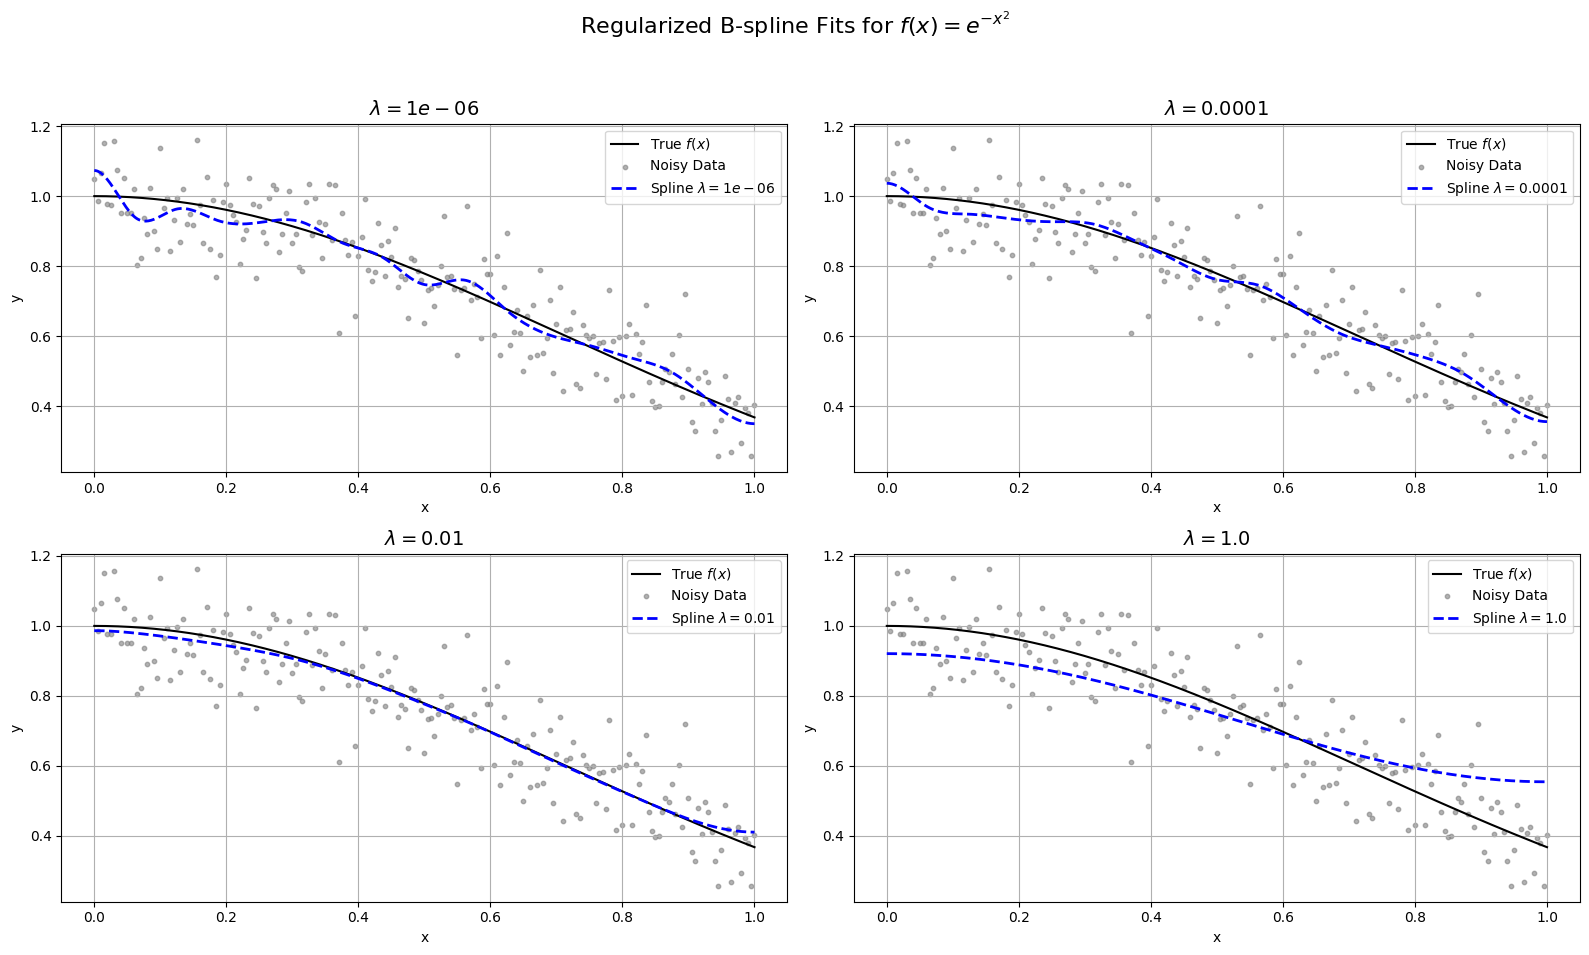

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Re-define helper functions if not guaranteed to be in kernel state
def f(x):
    return np.exp(-x**2)

def B_0(x, i, t_vec):
    if t_vec[i] <= x < t_vec[i+1]:
        return 1.0
    elif i == N - 1 and x == t_vec[i+1]: # Original problem's edge case for B_{N-1,0}(1)=1
        return 1.0
    else:
        return 0.0

def B(x, i, p_deg, t_vec):
    if p_deg == 0:
        global N # Access global N for B_0's special case
        return B_0(x, i, t_vec)

    alpha_num = x - t_vec[i]
    alpha_den = t_vec[i+p_deg] - t_vec[i]
    alpha = alpha_num / alpha_den if alpha_den != 0 else 0.0

    beta_num = t_vec[i+p_deg+1] - x
    beta_den = t_vec[i+p_deg+1] - t_vec[i+1]
    beta = beta_num / beta_den if beta_den != 0 else 0.0

    return alpha * B(x, i, p_deg - 1, t_vec) + beta * B(x, i+1, p_deg - 1, t_vec)

def evaluate_fitted_spline(x_eval, coefficients, B_func, p_deg, t_vec, N_basis):
    s_eval = np.zeros_like(x_eval)
    for idx_x, x_val in enumerate(x_eval):
        for i in range(N_basis):
            s_eval[idx_x] += coefficients[i] * B_func(x_val, i, p_deg, t_vec)
    return s_eval

# 1. Define regularization parameters
lambda_values = [1e-6, 1e-4, 1e-2, 1e0]

# 2. Create a fine grid for plotting
x_fine = np.linspace(0, 1, 500)
f_true_fine = f(x_fine)

# Prepare figure for plotting
plt.figure(figsize=(16, 10))
plt.suptitle('Regularized B-spline Fits for $f(x) = e^{-x^2}$', fontsize=16)

# 3. For each lambda value:
for idx, lambda_val in enumerate(lambda_values):
    # a. Compute the left-hand side of the normal equations
    LHS = A.T @ A + lambda_val * R

    # b. Compute the right-hand side
    RHS = A.T @ y_k

    # c. Solve for the coefficients
    c = np.linalg.solve(LHS, RHS)

    # d. Evaluate the fitted spline
    s_lambda_fine = evaluate_fitted_spline(x_fine, c, B, p, t, N)

    # e. Plot the true function, noisy data, and fitted spline
    plt.subplot(2, 2, idx + 1)
    plt.plot(x_fine, f_true_fine, 'k-', label='True $f(x)$')
    plt.scatter(x_k, y_k, s=10, alpha=0.6, color='gray', label='Noisy Data')
    plt.plot(x_fine, s_lambda_fine, 'b--', label=rf'Spline $\lambda = {lambda_val}$', linewidth=2)
    plt.title(rf'$\lambda = {lambda_val}$', fontsize=14)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

(b) (Computational) For each $\lambda$, report:
$$\text{(data misfit) } ||Ac - y||_2, \quad \text{(roughness) } c^T Rc, \quad \text{(true error) } ||f - s_\lambda||_\infty \text{ (on a fine grid)}$$

Calculating data misfit, roughness, and true error for each $\lambda$:

In [36]:
import numpy as np

# Re-define helper functions if not guaranteed to be in kernel state
def f(x):
    return np.exp(-x**2)

def B_0(x, i, t_vec):
    if t_vec[i] <= x < t_vec[i+1]:
        return 1.0
    elif i == N - 1 and x == t_vec[i+1]:
        return 1.0
    else:
        return 0.0

def B(x, i, p_deg, t_vec):
    if p_deg == 0:
        global N
        return B_0(x, i, t_vec)

    alpha_num = x - t_vec[i]
    alpha_den = t_vec[i+p_deg] - t_vec[i]
    alpha = alpha_num / alpha_den if alpha_den != 0 else 0.0

    beta_num = t_vec[i+p_deg+1] - x
    beta_den = t_vec[i+p_deg+1] - t_vec[i+1]
    beta = beta_num / beta_den if beta_den != 0 else 0.0

    return alpha * B(x, i, p_deg - 1, t_vec) + beta * B(x, i+1, p_deg - 1, t_vec)

def evaluate_fitted_spline(x_eval, coefficients, B_func, p_deg, t_vec, N_basis):
    s_eval = np.zeros_like(x_eval)
    for idx_x, x_val in enumerate(x_eval):
        for i in range(N_basis):
            s_eval[idx_x] += coefficients[i] * B_func(x_val, i, p_deg, t_vec)
    return s_eval


# Data and parameters from previous cells should be available:
# m, sigma, x_k, y_k, p, K, t, N, A, R

lambda_values = [1e-6, 1e-4, 1e-2, 1e0]
x_fine = np.linspace(0, 1, 500)
f_true_fine = f(x_fine)

print("Reporting metrics for each lambda value:")
print("-----------------------------------------------------------------------------------------")
print(f"{'Lambda':<10} | {'Data Misfit ||Ac - y||_2':<25} | {'Roughness c^T Rc':<20} | {'True Error ||f - s_lambda||_inf':<28}")
print("-----------------------------------------------------------------------------------------")

for lambda_val in lambda_values:
    # Solve for coefficients c
    LHS = A.T @ A + lambda_val * R
    RHS = A.T @ y_k
    c = np.linalg.solve(LHS, RHS)

    # Evaluate the fitted spline
    s_lambda_fine = evaluate_fitted_spline(x_fine, c, B, p, t, N)

    # Calculate Data Misfit: ||Ac - y||_2
    data_misfit = np.linalg.norm(A @ c - y_k, 2)

    # Calculate Roughness: c^T Rc
    roughness = c.T @ R @ c

    # Calculate True Error: ||f - s_lambda||_inf
    true_error = np.max(np.abs(f_true_fine - s_lambda_fine))

    print(f"{lambda_val:<10.0e} | {data_misfit:<25.6f} | {roughness:<20.6f} | {true_error:<28.6f}")

print("-----------------------------------------------------------------------------------------")

Reporting metrics for each lambda value:
-----------------------------------------------------------------------------------------
Lambda     | Data Misfit ||Ac - y||_2  | Roughness c^T Rc     | True Error ||f - s_lambda||_inf
-----------------------------------------------------------------------------------------
1e-06      | 1.262878                  | 989.807890           | 0.073229                    
1e-04      | 1.271193                  | 199.979470           | 0.040204                    
1e-02      | 1.314877                  | 6.696914             | 0.042987                    
1e+00      | 1.644492                  | 1.638160             | 0.186722                    
-----------------------------------------------------------------------------------------


(c) (Interpretation) Describe what increasing $\lambda$ does quantitatively. Which $\lambda$ best recovers $f$ (not merely smallest misfit)? Explain using the "fit + penalty" viewpoint.

Based on the summary report for metrics of each $\lambda$, increasing the value of $\lambda$ slightly increases the data misfit and true error. On the other hand, roughness decreases drastically. With small $\lambda$, the fitted splines behave like interpolation, resulting in a better fit in terms of data misfit and true error while having a very rough spline as a trade-off. $\lambda = 0.01$ appears to recover $f$ best as its data misfit has minimal difference in terms of other lambda values. It has low roughness while also having a low true error.

<div style="page-break-after: always;"></div>

# **Exercise 1.7** (Orthogonality characterization of the $L^2$ best approximation (real vs. complex))
Let $X$ be an innner-product space and $V \subset X$ a (linear) subspace. Given $f \in X$, consider the minimization problem
$$\min_{p \in V} ||f - p||_2$$
In this exercise you will prove the standard orthogonality characterization of the minimizer, first in the real case and then in the complex case.

(a) **(Real case: reproduce the proof)** Assume $X$ is a real inner-product space. Prove the following equivalence:
$$p^* \in V \text{ satisfies } ||f - p^*||_2 = \min_{p \in V} ||f - p||_2 \text{ if and only if } \langle f - p^*, v \rangle = 0 \text{ for all } v \in V$$
(Hint: Follow the exact structure of Section 1.3.1 of the course notes: for fixed $v \in V$, define $\psi(s) = ||f - (p^* + sv)||_2^2$ for $s \in \mathbb{R}$, expand $\psi$, and use $\psi'(0) = 0$)

$(\implies)$ Assume $p^* \in V$ is a minimizer. Show orthogonality. Fix any $v \in V$. For $s \in \mathbb{R}, p^* + sv$ lies in $V$ as well. By minimality,
$$||f - p^*||_2^2 \le ||f - (p^* + sv)||_2^2 \quad \text{for all } s \in \mathbb{R}$$
Define the real-valued function $\psi: \mathbb{R} \rightarrow \mathbb{R}$
$$\psi(s) = ||f - (p^* + sv)||_2^2$$
Expanding using bilinearity and symmetry of the (real) inner product,
$$\psi(s) = \langle f - p^* - sv, f - p^* - sv \rangle$$
$$= \langle f - p^*, f - p^* \rangle + \langle f - p^*, -sv \rangle + \langle -sv, f - p^* \rangle + \langle -sv, -sv \rangle$$
$$= ||f - p^*||_2^2 - 2s \langle f - p^*, v \rangle + s^2 ||v||_2^2$$
Since $s = 0$ is a minimizer of $\psi(s)$ (because $p^*$ is a minimizer over $V$ by assumption), the derivative at $s = 0$ must vanish:
$$0 = \psi'(0) = -2 \langle f - p^*, v \rangle$$
Hence $\langle f - p^*, v \rangle = 0$ for every $v \in V$, as desired.
\
$(\Longleftarrow)$ Assume orthogonality. Show $p^* \in V$ is a minimizer. Let $p \in V$ be arbitrary. Write $p = p^* + v$ where $v = p - p^* \in V$. Then
$$f - p = f - p^* - v$$
Compute the squared norm:
$$||f - p||_2^2 = \langle f - p^* - v, f - p^* - v \rangle = ||f - p^*||_2^2 - 2\langle f - p^*, v \rangle + ||v||_2^2$$
By the assumed orthogonality, $\langle f - p^*, v \rangle = 0$, s0
$$||f - p||_2^2 = ||f - p^*||_2^2 + ||v||_2^2 \ge ||f - p^*||_2^2$$
Taking square roots gives
$$||f - p||_2 \ge ||f - p^*||_2$$
for every $p \in V$ (since $p \in V$ was arbitrarily chosen). Therefore, $p^*$ minimizes $||f - p||_2$ over $V$.

(b) **(Complex case: what changes?)** Now assume $X$ is a complete inner-product space. Fix definiteness, use the convention that the inner product is linear in the first argument and conjugate-linear in the second and satisfied $\langle x, y \rangle = \overline{\langle y, x \rangle}$.
\
Prove the same equivalence:
$$p^* \in V \text{ satisfies } ||f - p^*||_2 = \min_{p \in V} ||f - p||_2 \text{ if and only if } \langle f - p^*, v \rangle = 0 \text{ for all } v \in V$$
(Hint 1: If you mimic the real proof with $s \in \mathbb{R}$, you will obtain an identity involving $Re\langle f - p^*, v \rangle$, that is, the real part of the inner product)
\
(Hint 2: To force the imaginary part to vanish as well, apply the same argument twice: once with direction $v$ and once with direction $iv$, where $i$ is the imaginary unit)

$(\implies)$ Assume $p^* \in V$ is a minimizer. Fix any $v \in V$ and consider the function $\psi(s) = ||f - (p^* + sv)||_2^2, s \in \mathbb{R}$. Since $P^*$ is a minimizer, $s = 0$ minimizes $\psi$.
$$\psi(s) = \langle f - p^* - sv, f - p^* - sv \rangle$$
$$= ||f - p^*||_2^2 - s \langle f - p^*, v \rangle - s \overline{\langle f - p^*, v \rangle} + s^2 ||v||_2^2$$
$$= ||f - p^*||_2^2 - 2s Re\langle f - p^*, v \rangle + s^2 ||v||_2^2$$
Thus,
$$\psi'(0) = -2 Re \langle f - p^*, v \rangle = 0$$
Hence, $\langle f - p^*, v \rangle = 0$ for all $v \in V$.
\
For $iv \in V$,
$$0 = Re\langle f - p^*, iv \rangle = Re(i\langle f - p^*, v \rangle ) = -Im\langle f - p^*, v \rangle$$
Hence, $\langle f - p^*, v \rangle = 0$ for all $v \in V$.
\
$(\Longleftarrow)$ Assume $\langle f - p^*, v \rangle = 0$ for all $v \in V$. Let $p \in V$ be arbitrary. Write $p = p^* + v$ with $v \in V$. Then,
$$||f - p||_2^2 = ||f - p^* - v||_2^2 = \langle f - p^* - v, f - p^* - v \rangle$$
$$= ||f - p^*||_2^2 - \langle f - p^*, v \rangle - \overline{\langle f - p^*, v \rangle} + ||v||_2^2$$
$$= ||f - p^*||_2^2 + ||v||_2^2 \ge ||f - p^*||_2^2$$
Taking square roots,
$$||f - p||_2 \ge ||f - p^*||_2$$
for every $p \in V$. Therefore, $p^*$ minimizes $||f - p||_2$ over $V$.

(c) **(Pythagorean Identity)** Assume the orthogonality condition holds: $\langle f - p^*, v \rangle = 0$ for all $v \in V$. Show that for every $p \in V$,
$$||f - p||_2^2 = ||f - p^*||_2^2 + ||p - p^*||_2^2$$

Let $p^* \in V$ satisfy $\langle f - p^*, v \rangle = 0$ for all $v \in V$. Fix any $p \in V$. Then, $p - p^* \in V$. By orthogonality, $\langle f - p^*, p - p^* \rangle = 0$. Then,
$$||f - p||_2^2 = \langle f - p, f - p \rangle = \langle (f - p^*) - (p - p^*), (f - p^*) - (p - p^*) \rangle$$
$$= ||f - p^*||_2^2 - \langle f - p^*, p - p^* \rangle - \overline{\langle f - p^*, p - p^* \rangle} + ||p - p^*||_2^2$$
Since $\langle f - p^*, p - p^* \rangle = 0$, this becomes $||f - p^*||_2^2 + ||p - p^*||_2^2$. Hence,
$||f - p||_2^2 = ||f - p^*||_2^2 + ||p - p^*||_2^2$.

<div style="page-break-after: always;"></div>

# **Exercise 1.8** (Derivative identities for (regularized) least squares)
Let $A \in \mathbb{R}^{m \times n}, y \in \mathbb{R}^m$, and let $R \in \mathbb{R}^{n \times n}$.
\
Define the objective
$$\Phi(c) = ||Ac - y||_2^2 + \lambda c^T Rc, \quad \lambda \ge 0$$
where $c \in \mathbb{R}^n$.

(a) **(Warm-up: expand into coordinates)** Write $||Ac - y||_2^2$ as a quadratic polynomial in $c$:
$$||Ac - y||_2^2 = c^T (A^T A)c - 2(A^T y)^T c + y^T y$$
(Show each step)

$$||Ac - y||_2^2 = (Ac - y)^T (Ac - y)$$
$$= (Ac)^T (Ac) - (Ac)^T y - y^T(Ac) + y^T y$$
where
$$(Ac)^T (Ac) = c^TA^TAc$$
$$(Ac)^Ty = c^TA^Ty$$
$$y^T(Ac) = (y^TA)c = (A^Ty)^Tc$$
Since these values are scalars, $c^TA^Ty = (A^Ty)^Tc$

Thus,
$$||Ac - y||_2^2 = c^TA^TAc - c^TA^Ty - (A^Ty)^Tc + y^Ty$$
$$ = c^T(A^TA)c - 2(A^Ty)^Tc + y^Ty$$

(b) **(Gradient of the data-misfit term)** Prove, in detail, that
$$\nabla_c ||Ac - y||_2^2 = 2A^T(Ac - y)$$
You may do this in either of the following ways (choose one):

(i) compute $\partial / \partial c_j$ componentwise and reassemble the vector, or

(ii) use a directional derivative: for fixed $h \in \mathbb{R}^n$, define $\psi(s) = ||A(c + sh) - y||_2^2$ and identify $\nabla \phi(c)$ from $\psi'(0)$

Let $\phi(c) = ||Ac - y||_2^2$. Fix an arbitrary direction $h \in \mathbb{R}^n$. Define the scalar function
$$\psi(s) = \phi(c + sh) = ||A(c + sh) - y||_2^2, \quad s \in \mathbb{R}$$
Then,
$$\psi(s) = ||Ac + sAh - y||_2^2 = (Ac - y + sAh)^T(Ac - y + sAh)$$
$$= (Ac - y)^T(Ac - y) + 2s(Ah)^T(Ac - y) + s^2(Ah)^T(Ah)$$
Taking the derivative, we have
$$\psi'(s) = 2(Ah)^T(Ac - y) + 2s(Ah)^T(Ah)$$
Evaluating at $s = 0$,
$$\psi'(0) = 2(Ah)^T(Ac - y)$$
By definition of the gradient,
$$\psi'(0) = \langle \nabla \phi(c), h \rangle = h^T \nabla \phi(c)$$
We can rewrite
$$2(Ah)^T(Ac - y) = 2h^TA^T(Ac - y)$$
Thus, for every $h \in \mathbb{R}^n$,
$$h^T \nabla \phi(c) = h^T[2A^T(Ac - y)]$$
Thus,
$$\nabla_c ||Ac - y||_2^2 = 2A^T (Ac - y)$$

(c) **(Gradient of the quadratic penalty)** Show that for general $R$,
$$\nabla_c (c^T Rc) = (R + R^T)c$$
Deduce the simplified form $\nabla_c(c^T Rc) = 2Rc$ when $R$ is symmetric.

Let $\phi(c) = c^TRc, c \in \mathbb{R}^n$ where $R \in \mathbb{R}^{n \times n}$. Fix an arbitrary direction $h \in \mathbb{R}^n$. Define
$$\psi(s) = \phi(c + sh) = (c + sh)^T (c + sh), \quad s \in \mathbb{R}$$
Expanding,
$$\psi(s) = c^TRc + sh^TRc + sc^TRh + s^2h^TRh$$
Differentiating,
$$\psi'(s) = h^TRc + c^TRh + 2sh^TRh$$
Evaluating at $s = 0$,
$$\psi'(0) = h^T Rc + c^TRh$$
Since $c^TRh$ is a scalar, $c^TRh = (c^TRh)^T = h^TR^Tc$. Thus, $\psi'(0) = h^T(R + R^T)c$. By definition of gradient,
$$\psi'(0) = h^T \nabla \phi(c) \text{ for all } h \in \mathbb{R}^n$$
Hence, $\nabla_c(c^TRc) = (R + R^T)c$. If $R$ is symmetric, $R^T = R$ so $\nabla_c (c^TRc) = 2Rc$.

(d) **(First-order optimality condition)** Consider parts (b) and (c) to show that critical points satisfy
$$\nabla \phi(c) = 0 \iff (A^TA + \lambda R)c = A^Ty$$
(assuming $R$ is symmmetric)

Recall
$$\phi(c) = ||Ac - y||_2^2 + \lambda c^T Rc, \quad \lambda \ge 0 \text{ with } R = R^T$$
From part (b),
$$\nabla_c ||Ac - y||_2^2 = 2A^T (Ac - y)$$
From part (c), since $R$ is symmetric,
$$\nabla_c(c^TRc) = 2Rc$$
Therefore,
$$\nabla \phi(c) = \nabla||Ac - y||_2^2 + \lambda \nabla(c^TRc) = 2A^T(Ac - y) + 2\lambda Rc$$
Critical points satisfy
$$\nabla \phi(c) = 0 \iff 2A^T (Ac - y) + 2\lambda Rc = 0$$
$$\implies \nabla \phi(c) = 0 \iff A^T(Ac - y) + \lambda Rc = 0$$
Expanding the right-hand side, we get
$$A^T(Ac - y) + \lambda Rc = 0 \implies A^TAc - A^Ty + \lambda Rc = 0$$
$$\implies (A^TA + \lambda R)c = A^Ty$$